# Decision Point Velocity Analysis

Classify every internal decision node (non-leaf, non R/L5XX) as **IMPORTANT** or **NON-IMPORTANT** based on the graph structure and current reward port configuration, then compare:
- Dwell time (frames / seconds) at the decision node
- Arrival speed (px/s) in a ±0.5 s window around the node visit

**IMPORTANT node**: from the current traversal direction, both forward branches lead to subtrees containing at least one reward port (real goal).  
**NON-IMPORTANT node**: only one forward branch leads to a reward port; the other is a dead-end (non-reward leaf).

Going-back events (mouse returns to the direction it came from) are counted but excluded from the main analysis.

### Within-patch dwelling
Patch pairs (by Target index): [1,2], [3,4], [5,6], [7,8].  
The **within-patch IMPORTANT node** is the graph node that separates the two goals of the same patch.  
A secondary analysis tests whether dwell time at these nodes differs when the mouse is about to **stay in patch** (cycle to the other port of the same pair) vs **leave the patch** (head toward a port from a different pair).

In [57]:
import ast
import importlib.util
import pickle
import re
import sys
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Import speed_analysis directly from file to avoid omegaconf dependency
_sa_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/navigraph/analysis/speed_analysis.py')
_spec = importlib.util.spec_from_file_location("speed_analysis", _sa_path)
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
compute_path_speed = _mod.compute_path_speed

# ── paths & constants ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs')
GRAPH_PKL    = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
FPS          = 40.0
FRAME_COL    = ('frame_idx_global', '')
X_COL        = ('headstage', 'x')
Y_COL        = ('headstage', 'y')
SMOOTH_WIN   = 5           # frames for speed smoothing (passed to compute_path_speed)
VEL_WIN_S    = 0.25        # half-window in seconds for speed window around node (total = 0.5s)
VEL_WIN_FR   = int(VEL_WIN_S * FPS)  # = 10 frames

SESSIONS = sorted(
    [d.name for d in BASE_DIR.iterdir()
     if d.is_dir() and (d/'traversal_df.csv').exists() and (d/'summary_df.pkl').exists()]
)
print(f"{len(SESSIONS)} sessions found:", SESSIONS)

14 sessions found: ['01_09_2025', '07_08_2025', '09_09_2025', '10_09_2025', '11_09_2025', '12_08_2025', '13_08_2025', '14_08_2025', '18_08_2025', '19_08_2025', '20_08_2025', '21_08_2025', '24_08_2025', '27_08_2025']


In [58]:
# ── Load graph G (same logic as change_of_mind.ipynb cell 4) ──────────────────
with open(GRAPH_PKL, 'rb') as f:
    mapping_data = pickle.load(f)

nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    if polygon and len(polygon) >= 2:
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        node_positions[node_id] = (sum(xs)/len(xs), sum(ys)/len(ys))

G = nx.DiGraph()
G.add_nodes_from(node_positions.keys())
for edge_key in edges_dict.keys():
    parts = edge_key.split('_')
    if len(parts) == 2:
        a, b = parts
        if a in node_positions and b in node_positions:
            G.add_edge(a, b)
            G.add_edge(b, a)

Gu = G.to_undirected()
print(f"Graph: {len(Gu.nodes())} nodes, {len(Gu.edges())} undirected edges")

# Leaf nodes: R/L5XX (reward or dead-end terminals — never decision points)
LEAF_RE = re.compile(r'^[RL]5\d+$')
leaf_nodes     = {n for n in Gu.nodes() if LEAF_RE.match(n)}
internal_nodes = {n for n in Gu.nodes() if not LEAF_RE.match(n)}

# Parent-of-leaf nodes: internal nodes that have at least one leaf neighbour.
# These are the L/R4XX nodes — they sit directly above the leaf layer.
# They are excluded from statistics entirely (like leaves), because any visit
# to them is either: (a) arrived from parent → trivially non-important (one
# branch goes to reward leaf, other to dead-end leaf) with no meaningful choice,
# or (b) arrived from a leaf → already excluded as a dead-end return.
parent_of_leaf_nodes = {n for n in internal_nodes
                        if any(LEAF_RE.match(nb) for nb in Gu.neighbors(n))}

# True decision nodes: the nodes that actually enter the statistics
decision_nodes = internal_nodes - parent_of_leaf_nodes

print(f"Leaf nodes        (R/L5XX, excluded):         {len(leaf_nodes)}")
print(f"Parent-of-leaf    (R/L4XX, excluded):         {len(parent_of_leaf_nodes)}")
print(f"True decision nodes (enter statistics):        {len(decision_nodes)}")

Graph: 126 nodes, 125 undirected edges
Leaf nodes        (R/L5XX, excluded):         64
Parent-of-leaf    (R/L4XX, excluded):         32
True decision nodes (enter statistics):        30


In [59]:
# ── Port maps and patch definitions (from change_of_mind.ipynb cell 5) ─────────
# Switch date: after 07/09/2025 R59↔R55 for Target7/Target8.
PORT_MAP_BEFORE = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R55':  'Target7', 'R59':  'Target8',
}
PORT_MAP_AFTER = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R59':  'Target7', 'R55':  'Target8',
}

# Patch pairs: Target number pairs that share a physical arm
PATCH_PAIRS = [(1, 2), (3, 4), (5, 6), (7, 8)]

def get_port_map(session_name: str) -> dict:
    dd, mm, yyyy = session_name.split('_')
    if mm == '09' and int(dd) >= 7:
        return PORT_MAP_AFTER
    return PORT_MAP_BEFORE

# Within-patch IMPORTANT nodes: the graph junction that separates the two goals
# of each patch.  These are the same regardless of the R55/R59 label swap.
#
#  Patch (1,2): R522 and R526 → both reachable via R11 (children R22, R23)
#  Patch (3,4): L56  and L510 → both reachable via L10 (children L20, L21)
#  Patch (5,6): L521 and L525 → both reachable via L11 (children L22, L23)
#  Patch (7,8): R59  and R55  → both reachable via R10 (children R20, R21)
WITHIN_PATCH_INFO = {
    'R11': {'patch': (1, 2), 'patch_children': {'R22', 'R23'}, 'parent': 'R0'},
    'L10': {'patch': (3, 4), 'patch_children': {'L20', 'L21'}, 'parent': 'L0'},
    'L11': {'patch': (5, 6), 'patch_children': {'L22', 'L23'}, 'parent': 'L0'},
    'R10': {'patch': (7, 8), 'patch_children': {'R20', 'R21'}, 'parent': 'R0'},
}
WITHIN_PATCH_NODES = set(WITHIN_PATCH_INFO.keys())

# Helper: which patch (1-indexed) does a target number belong to?
def target_to_patch(target_num: int) -> tuple:
    for pair in PATCH_PAIRS:
        if target_num in pair:
            return pair
    return None

print("Port maps and patch definitions loaded.")
print("Within-patch IMPORTANT nodes:", sorted(WITHIN_PATCH_NODES))

Port maps and patch definitions loaded.
Within-patch IMPORTANT nodes: ['L10', 'L11', 'R10', 'R11']


In [60]:
# ── Decision node classifier ───────────────────────────────────────────────────

def subtree_reward_nodes(start_child: str, barrier_node: str, reward_set: set) -> set:
    """BFS from start_child away from barrier_node; return reward nodes found."""
    seen = {barrier_node}
    queue = [start_child]
    found = set()
    while queue:
        n = queue.pop(0)
        if n in seen:
            continue
        seen.add(n)
        if n in reward_set:
            found.add(n)
        for nb in Gu.neighbors(n):
            if nb not in seen:
                queue.append(nb)
    return found


def _raw_classify(node: str, came_from: str, reward_set: set) -> str | None:
    """
    Internal classifier used only to compute always/sometimes/never sets.
    Returns 'important' if both forward branches reach reward, 'non_important'
    if only one does, None otherwise.
    """
    if LEAF_RE.match(node):             return None
    if node in parent_of_leaf_nodes:    return None
    if LEAF_RE.match(came_from):        return None
    children = [n for n in Gu.neighbors(node) if n != came_from]
    if len(children) < 2:               return None
    child_has_reward = [
        len(subtree_reward_nodes(child, node, reward_set)) > 0
        for child in children
    ]
    if all(child_has_reward):   return 'important'
    if any(child_has_reward):   return 'non_important'
    return None


# ── Structural summary over true decision nodes only ───────────────────────────
reward_set_after = set(PORT_MAP_AFTER.keys())

always_imp    = set()
sometimes_imp = set()
never_imp     = set()

for n in sorted(decision_nodes):
    results = set()
    for came_from in Gu.neighbors(n):
        c = _raw_classify(n, came_from, reward_set_after)
        if c:
            results.add(c)
    if not results:
        never_imp.add(n)
    elif results == {'important'}:
        always_imp.add(n)
    elif 'important' in results:
        sometimes_imp.add(n)
    else:
        never_imp.add(n)


# ── Updated classify_decision ──────────────────────────────────────────────────
# 'Sometimes-important' nodes: from one approach direction both forward branches
# technically reach rewards, but the multi-reward branch is just the main trunk —
# the same single path leading back to the rest of the maze, not a true fork
# between distinct reward subtrees. The choice is always between going toward one
# local reward vs. going away from it; neither direction represents a genuine
# bifurcation. Only 'always-important' nodes — where every approach direction
# presents a real fork between distinct reward subtrees — are labelled 'important'.
# Sometimes-important nodes are always 'non_important' here; their toward/away
# direction is analysed separately in the section below.

def classify_decision(node: str, came_from: str, reward_set: set) -> str | None:
    """
    Returns 'important', 'non_important', or None.
    'important' only for always-important nodes (genuine fork between distinct
    reward subtrees from every approach direction).
    Sometimes-important nodes → always 'non_important'.
    """
    if LEAF_RE.match(node):             return None
    if node in parent_of_leaf_nodes:    return None
    if LEAF_RE.match(came_from):        return None
    children = [n for n in Gu.neighbors(node) if n != came_from]
    if len(children) < 2:               return None
    child_has_reward = [
        len(subtree_reward_nodes(child, node, reward_set)) > 0
        for child in children
    ]
    if not any(child_has_reward):
        return None
    if node in always_imp and all(child_has_reward):
        return 'important'
    return 'non_important'


# ── Graph hop-distance to nearest reward ──────────────────────────────────────
# Used for toward/away-from-reward labelling at sometimes-important nodes.
# Union of both port maps so all reward leaves are included regardless of session.
_all_reward_nodes = set(PORT_MAP_BEFORE.keys()) | set(PORT_MAP_AFTER.keys())
min_rwd_dist: dict[str, float] = {n: float('inf') for n in Gu.nodes()}
for _rn in _all_reward_nodes:
    if _rn not in Gu:
        continue
    for _n, _d in nx.single_source_shortest_path_length(Gu, _rn).items():
        if _d < min_rwd_dist[_n]:
            min_rwd_dist[_n] = _d

print("ALWAYS IMPORTANT:  ", sorted(always_imp))
print(f"SOMETIMES IMPORTANT (→ non_important in main stats; "
      f"toward/away sub-analysis below): {len(sometimes_imp)} nodes")
print(f"NEVER IMPORTANT:     {len(never_imp)} nodes")
print(f"EXCLUDED (parent-of-leaf): {len(parent_of_leaf_nodes)} nodes")
print()
print("Within-patch nodes ∩ always-important:", WITHIN_PATCH_NODES & always_imp)
print("Between-patch always-important nodes:",  sorted(always_imp - WITHIN_PATCH_NODES))

ALWAYS IMPORTANT:   ['L0', 'L10', 'L11', 'R0', 'R10', 'R11']
SOMETIMES IMPORTANT (→ non_important in main stats; toward/away sub-analysis below): 16 nodes
NEVER IMPORTANT:     8 nodes
EXCLUDED (parent-of-leaf): 32 nodes

Within-patch nodes ∩ always-important: {'L11', 'R10', 'L10', 'R11'}
Between-patch always-important nodes: ['L0', 'R0']


In [61]:
# ── Per-direction summary for every 'sometimes-important' node ─────────────────
# For each (node, came_from) pair that is structurally valid, show:
#   • the toward/away-from-reward label for each forward branch (hop-distance based)
#   • which reward Targets are reachable via each branch
#
# Leaf arrivals excluded. Direction is determined by comparing hop-distance to the
# nearest reward for each forward child vs. the came_from node.

node_to_target = PORT_MAP_AFTER
target_short   = {v: v.replace('Target', 'T') for v in PORT_MAP_AFTER.values()}

def branch_target_str(node, came_from, rs):
    """Return list of (child_node, toward_away_label, [short_target_labels])."""
    children = [n for n in Gu.neighbors(node) if n != came_from]
    d_came   = min_rwd_dist.get(came_from, float('inf'))
    out = []
    for child in children:
        rw     = subtree_reward_nodes(child, node, rs)
        labels = sorted(target_short[node_to_target[r]] for r in rw if r in node_to_target)
        d_child = min_rwd_dist.get(child, float('inf'))
        if d_child < d_came:
            direction = 'TOWARD'
        elif d_child > d_came:
            direction = 'AWAY'
        else:
            direction = 'NEUTRAL'
        out.append((child, direction, labels))
    return out

rows = []
for n in sorted(sometimes_imp):
    for came_from in sorted(Gu.neighbors(n)):
        if LEAF_RE.match(came_from):
            continue
        cls = _raw_classify(n, came_from, reward_set_after)
        if cls is None:
            continue
        branches = branch_target_str(n, came_from, reward_set_after)
        rows.append({
            'node':             n,
            'came_from':        came_from,
            'raw_cls':          cls,
            'branch_A':         branches[0][0],
            'branch_A_dir':     branches[0][1],
            'branch_A_targets': ', '.join(branches[0][2]) if branches[0][2] else '—',
            'branch_B':         branches[1][0],
            'branch_B_dir':     branches[1][1],
            'branch_B_targets': ', '.join(branches[1][2]) if branches[1][2] else '—',
        })

df_sometimes = pd.DataFrame(rows)

W = 110
print('=' * W)
print('SOMETIMES-IMPORTANT nodes — per-direction view  (port map: after 07/09/2025)')
print('Direction = TOWARD/AWAY from nearest reward (hop distance of child vs. came_from).')
print('All these directions are classified as non_important in the main analysis.')
print('=' * W)
print(f"{'Node':<6}  {'Came from':<10}  {'raw_cls':<14}  "
      f"{'Branch A':<8} {'dir':<8} {'targets':<20}  "
      f"{'Branch B':<8} {'dir':<8} targets")
print('-' * W)

prev_node = None
for _, r in df_sometimes.iterrows():
    node_col = r['node'] if r['node'] != prev_node else ''
    ba = f"{r['branch_A']:<8} {r['branch_A_dir']:<8} [{r['branch_A_targets']}]"
    bb = f"{r['branch_B']:<8} {r['branch_B_dir']:<8} [{r['branch_B_targets']}]"
    print(f"{node_col:<6}  from {r['came_from']:<7}  {r['raw_cls']:<14}  {ba:<38}  {bb}")
    prev_node = r['node']

print()
print("raw_cls = what the old logic returned (now overridden: all these nodes → non_important).")
print("TOWARD  = child is closer to nearest reward than came_from (hop count).")
print("AWAY    = child is farther from nearest reward than came_from.")

SOMETIMES-IMPORTANT nodes — per-direction view  (port map: after 07/09/2025)
Direction = TOWARD/AWAY from nearest reward (hop distance of child vs. came_from).
All these directions are classified as non_important in the main analysis.
Node    Came from   raw_cls         Branch A dir      targets               Branch B dir      targets
--------------------------------------------------------------------------------------------------------------
L20     from L10      non_important   L30      NEUTRAL  [—]                   L31      TOWARD   [T3]
        from L30      important       L10      NEUTRAL  [T1, T2, T4, T5, T6, T7, T8]  L31      TOWARD   [T3]
        from L31      non_important   L30      AWAY     [—]                   L10      AWAY     [T1, T2, T4, T5, T6, T7, T8]
L21     from L10      non_important   L33      NEUTRAL  [—]                   L32      TOWARD   [T4]
        from L32      non_important   L10      AWAY     [T1, T2, T3, T5, T6, T7, T8]  L33      AWAY     [—]
        

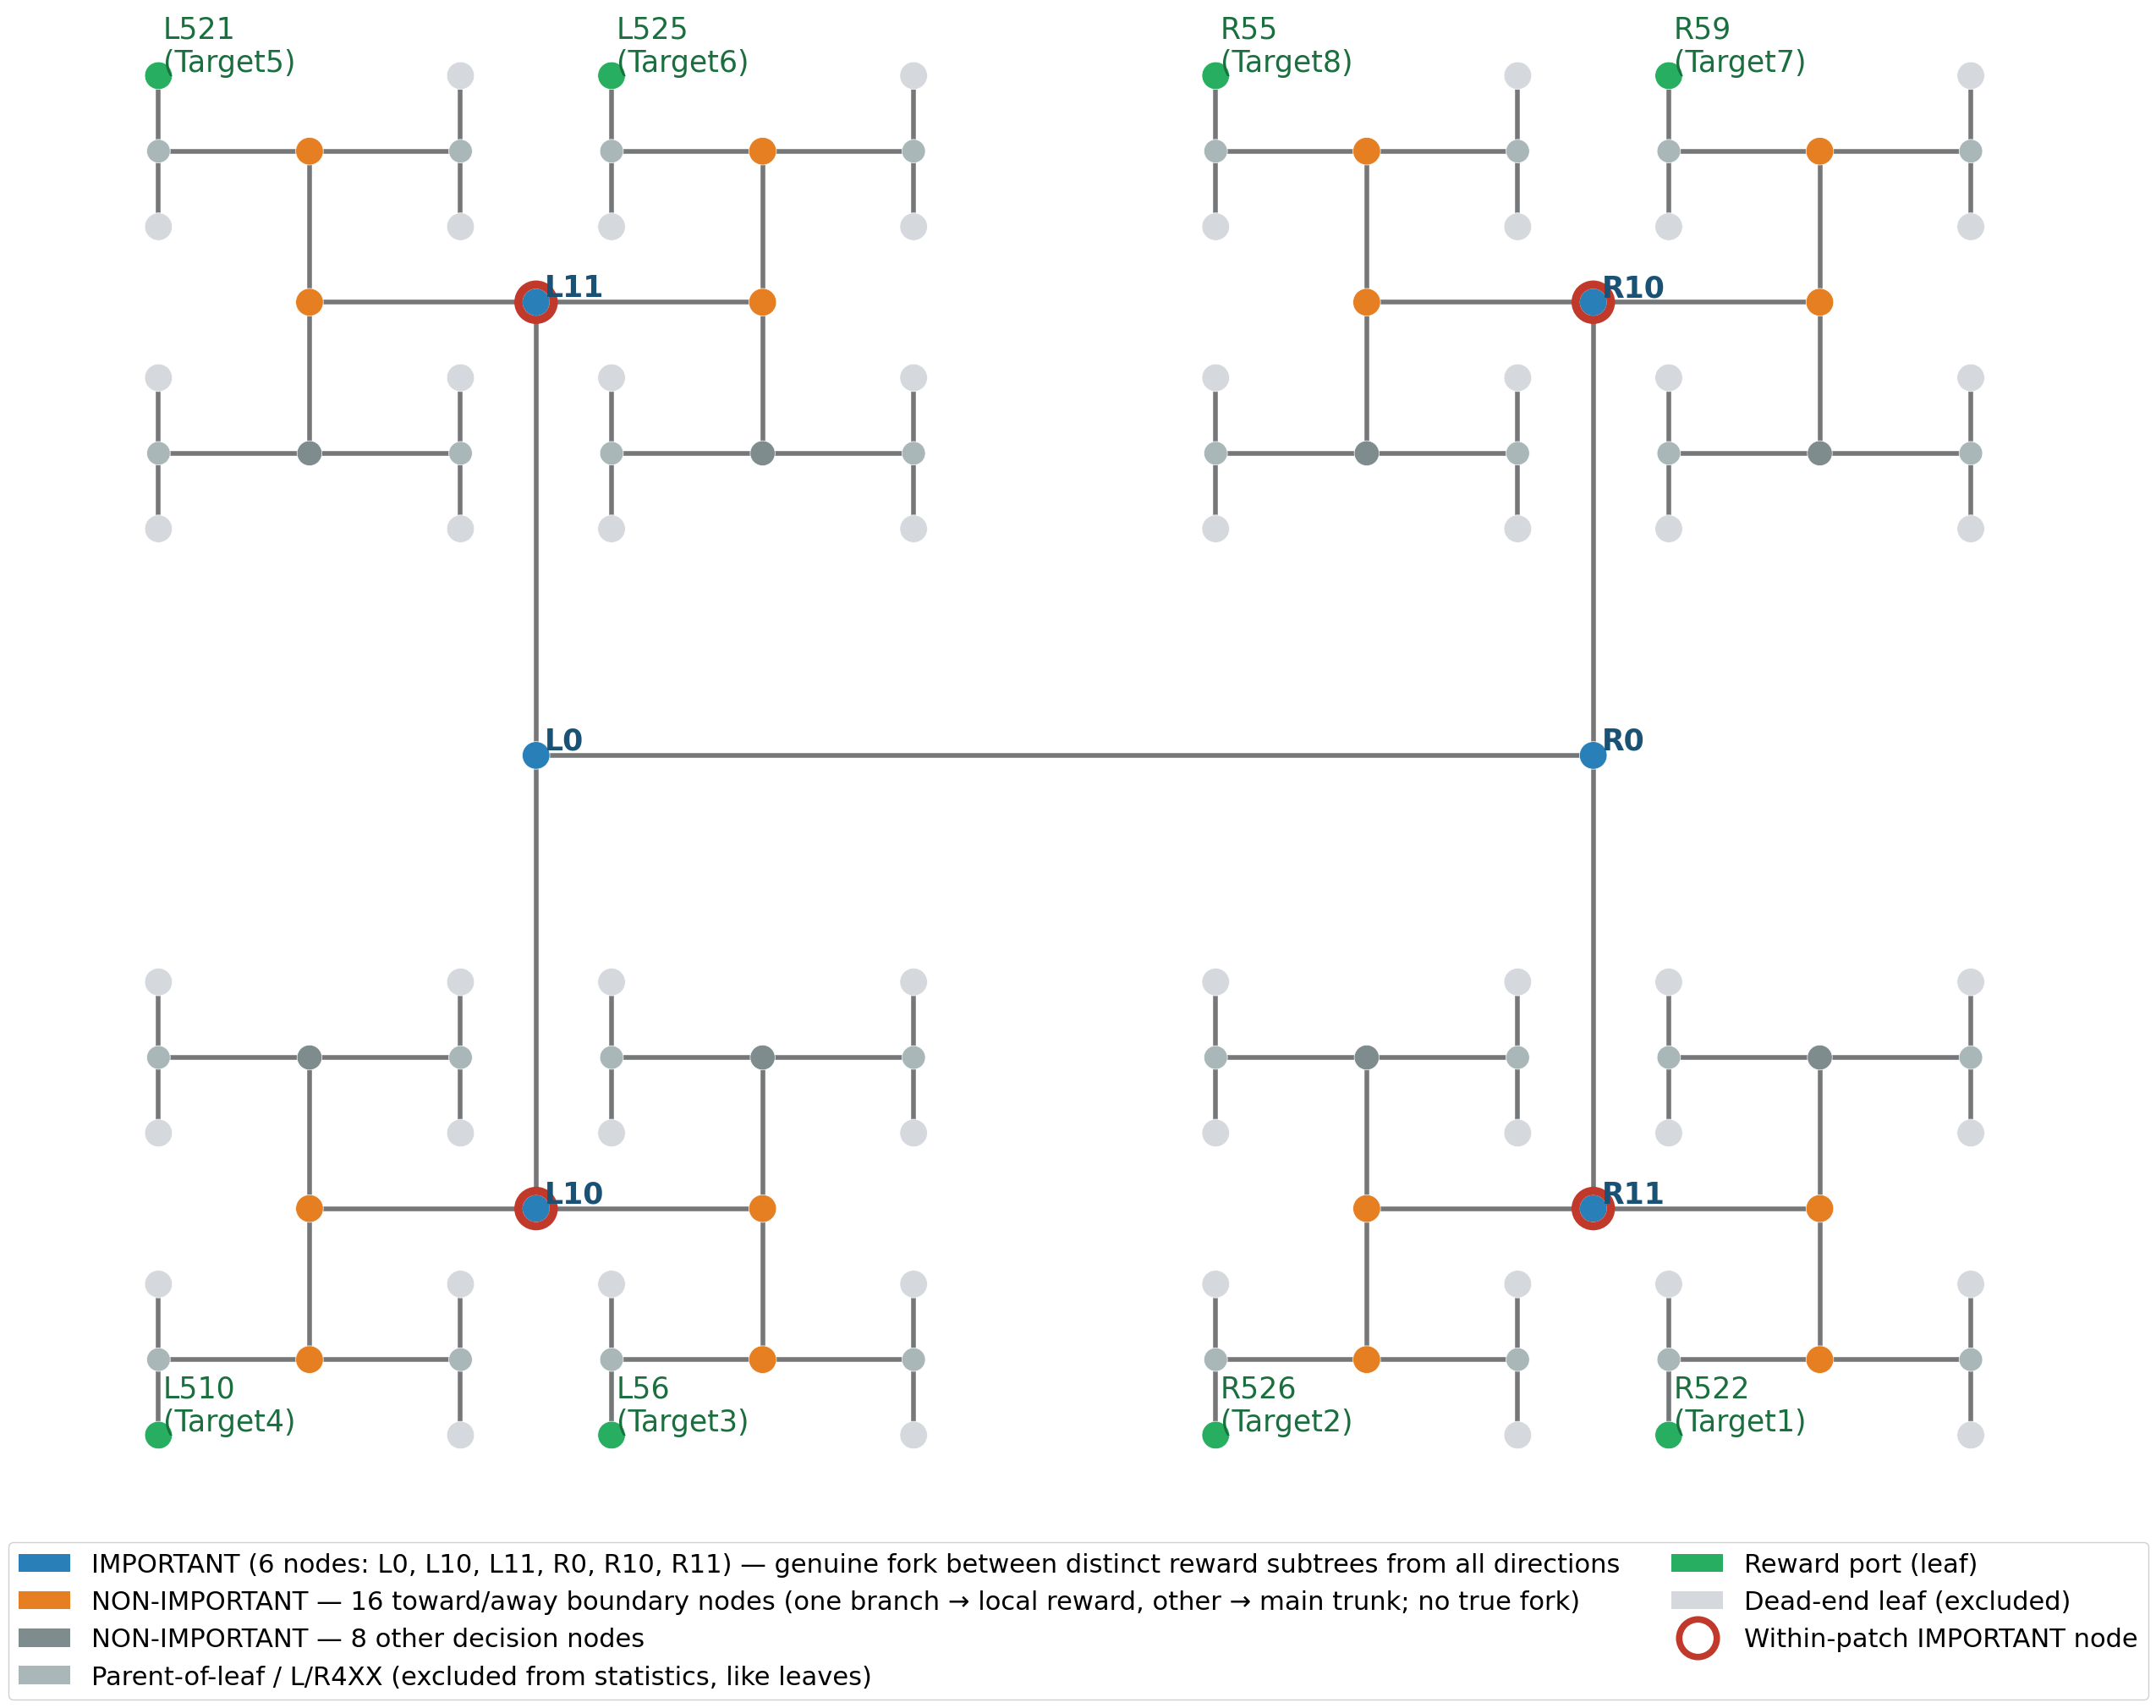

In [62]:
# ── Graph G: visualise node importance classification ─────────────────────────
C_ALWAYS       = '#2980b9'   # blue        – IMPORTANT (always_imp)
C_SOMETIMES    = '#e67e22'   # orange      – NON-IMPORTANT (toward/away boundary nodes)
C_NEVER        = '#7f8c8d'   # gray        – NON-IMPORTANT (other)
C_POL          = '#aab7b8'   # light gray  – parent-of-leaf (L/R4XX, excluded like leaves)
C_LEAF_RWD     = '#27ae60'   # green       – leaf that IS a reward port
C_LEAF_NORWD   = '#d5d8dc'   # very light  – dead-end leaf, no reward
C_PATCH_RING   = '#c0392b'   # red ring    – within-patch IMPORTANT node

reward_leaves = set(PORT_MAP_AFTER.keys())

def node_style(n):
    if LEAF_RE.match(n):
        return (C_LEAF_RWD if n in reward_leaves else C_LEAF_NORWD, 550, 1)
    if n in parent_of_leaf_nodes:
        return (C_POL, 400, 2)          # excluded — shown but clearly muted
    if n in always_imp:
        return (C_ALWAYS, 550, 4)
    if n in sometimes_imp:
        return (C_SOMETIMES, 550, 3)
    return (C_NEVER, 450, 2)

fig, ax = plt.subplots(figsize=(30, 20))

for u, v in Gu.edges():
    if u in node_positions and v in node_positions:
        x0, y0 = node_positions[u]
        x1, y1 = node_positions[v]
        ax.plot([x0, x1], [y0, y1], '-', color="#767778", linewidth=4, zorder=1)

for layer in [C_LEAF_NORWD, C_LEAF_RWD, C_POL, C_NEVER, C_SOMETIMES, C_ALWAYS]:
    layer_nodes = [n for n in Gu.nodes()
                   if n in node_positions and node_style(n)[0] == layer]
    if not layer_nodes:
        continue
    xs    = [node_positions[n][0] for n in layer_nodes]
    ys    = [node_positions[n][1] for n in layer_nodes]
    sizes = [node_style(n)[1] for n in layer_nodes]
    ax.scatter(xs, ys, s=sizes, c=layer, zorder=node_style(layer_nodes[0])[2],
               edgecolors='white', linewidths=0.5)

for n in WITHIN_PATCH_NODES:
    if n in node_positions:
        x, y = node_positions[n]
        ax.scatter([x], [y], s=900, facecolors='none',
                   edgecolors=C_PATCH_RING, linewidths=7, zorder=5)

for n in sorted(always_imp):
    if n in node_positions:
        x, y = node_positions[n]
        ax.annotate(n, (x, y), textcoords='offset points', xytext=(7, 5),
                    fontsize=25, fontweight='bold', color='#1a5276', zorder=6)

label_map = {v: k for k, v in PORT_MAP_AFTER.items()}
for target, node in label_map.items():
    if node in node_positions:
        x, y = node_positions[node]
        ax.annotate(f"{node}\n({target})", (x, y),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=25, color='#196f3d', zorder=6)

from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor=C_ALWAYS,
                   label=f'IMPORTANT ({len(always_imp)} nodes: '
                         + ', '.join(sorted(always_imp))
                         + ') — genuine fork between distinct reward subtrees from all directions'),
    mpatches.Patch(facecolor=C_SOMETIMES,
                   label=f'NON-IMPORTANT — {len(sometimes_imp)} toward/away boundary nodes'
                         ' (one branch → local reward, other → main trunk; no true fork)'),
    mpatches.Patch(facecolor=C_NEVER,
                   label=f'NON-IMPORTANT — {len(never_imp)} other decision nodes'),
    mpatches.Patch(facecolor=C_POL,
                   label='Parent-of-leaf / L/R4XX (excluded from statistics, like leaves)'),
    mpatches.Patch(facecolor=C_LEAF_RWD,   label='Reward port (leaf)'),
    mpatches.Patch(facecolor=C_LEAF_NORWD,  label='Dead-end leaf (excluded)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=C_PATCH_RING, markersize=32, markeredgewidth=5.5,
           label='Within-patch IMPORTANT node'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=22,
          framealpha=0.92, bbox_to_anchor=(0.5, -0.14))

# ax.set_title(
#     'Graph G — Decision node importance classification\n'
#     'Blue = IMPORTANT (always-important, genuine reward fork)  |  '
#     'Orange = NON-IMPORTANT boundary nodes (toward/away)  |  '
#     'Gray = NON-IMPORTANT other  |  L/R4XX excluded like leaves',
#     fontsize=10, fontweight='bold')
ax.set_xlim(50, 900)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

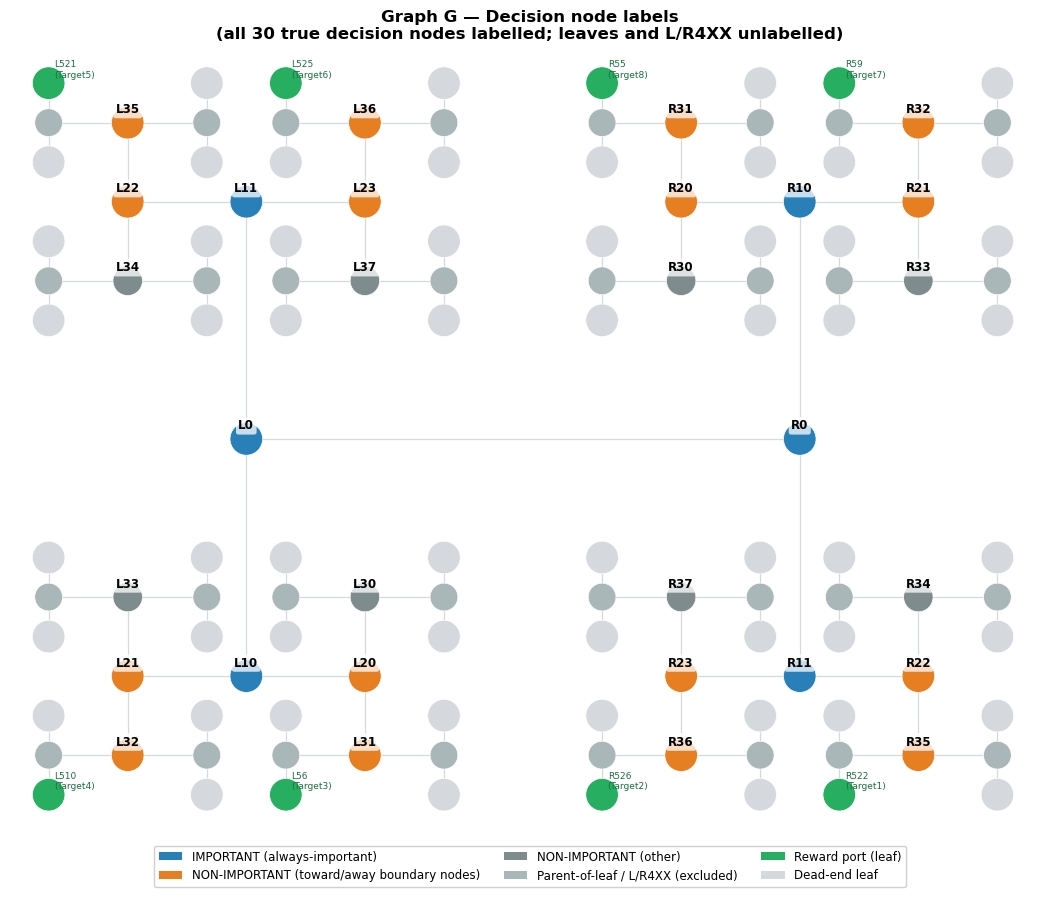

In [63]:
# ── Graph G: same layout, node labels for all decision nodes ──────────────────
fig, ax = plt.subplots(figsize=(15, 9))

for u, v in Gu.edges():
    if u in node_positions and v in node_positions:
        x0, y0 = node_positions[u]
        x1, y1 = node_positions[v]
        ax.plot([x0, x1], [y0, y1], '-', color='#d5d8dc', linewidth=0.9, zorder=1)

for layer in [C_LEAF_NORWD, C_LEAF_RWD, C_POL, C_NEVER, C_SOMETIMES, C_ALWAYS]:
    layer_nodes = [n for n in Gu.nodes()
                   if n in node_positions and node_style(n)[0] == layer]
    if not layer_nodes:
        continue
    xs    = [node_positions[n][0] for n in layer_nodes]
    ys    = [node_positions[n][1] for n in layer_nodes]
    sizes = [node_style(n)[1] for n in layer_nodes]
    ax.scatter(xs, ys, s=sizes, c=layer, zorder=node_style(layer_nodes[0])[2],
               edgecolors='white', linewidths=0.5)

# Label every decision node (not leaf, not parent-of-leaf)
for n in sorted(decision_nodes):
    if n not in node_positions:
        continue
    x, y = node_positions[n]
    ax.annotate(
        n, (x, y),
        textcoords='offset points', xytext=(0, 7),
        fontsize=8.5, fontweight='bold',
        color='black',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
        zorder=7,
    )

# Label reward leaf nodes (green dots) with node name and Target
label_map = {v: k for k, v in PORT_MAP_AFTER.items()}
for target, node in label_map.items():
    if node in node_positions:
        x, y = node_positions[node]
        ax.annotate(f"{node}\n({target})", (x, y),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=6.5, color='#196f3d', zorder=6)

from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor=C_ALWAYS,     label='IMPORTANT (always-important)'),
    mpatches.Patch(facecolor=C_SOMETIMES,  label='NON-IMPORTANT (toward/away boundary nodes)'),
    mpatches.Patch(facecolor=C_NEVER,      label='NON-IMPORTANT (other)'),
    mpatches.Patch(facecolor=C_POL,        label='Parent-of-leaf / L/R4XX (excluded)'),
    mpatches.Patch(facecolor=C_LEAF_RWD,   label='Reward port (leaf)'),
    mpatches.Patch(facecolor=C_LEAF_NORWD,  label='Dead-end leaf'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=8.5,
          framealpha=0.92, bbox_to_anchor=(0.5, -0.08))

ax.set_title('Graph G — Decision node labels\n'
             '(all 30 true decision nodes labelled; leaves and L/R4XX unlabelled)',
             fontsize=12, fontweight='bold')
ax.set_xlim(50, 900)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

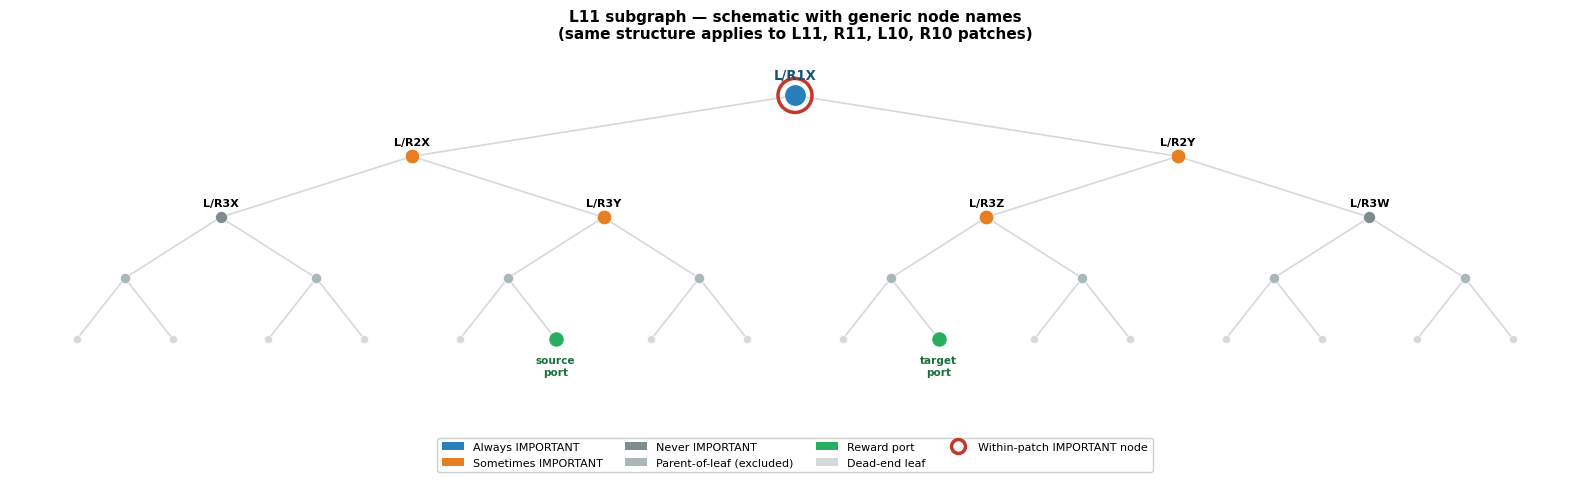

In [64]:
# ── Schematic: L11 subgraph with generic node names ───────────────────────────
# Structure derived from BFS of L11 subtree (barrier = L0).
# Patch (5,6): L521 → Target5, L525 → Target6.

_EDGES_SCH = [
    ('L11', 'L22'), ('L11', 'L23'),
    ('L22', 'L34'), ('L22', 'L35'),
    ('L23', 'L36'), ('L23', 'L37'),
    ('L34', 'L48'),  ('L34', 'L49'),
    ('L35', 'L410'), ('L35', 'L411'),
    ('L36', 'L412'), ('L36', 'L413'),
    ('L37', 'L414'), ('L37', 'L415'),
    ('L48',  'L516'), ('L48',  'L517'),
    ('L49',  'L518'), ('L49',  'L519'),
    ('L410', 'L520'), ('L410', 'L521'),
    ('L411', 'L522'), ('L411', 'L523'),
    ('L412', 'L524'), ('L412', 'L525'),
    ('L413', 'L526'), ('L413', 'L527'),
    ('L414', 'L528'), ('L414', 'L529'),
    ('L415', 'L530'), ('L415', 'L531'),
]

# Hierarchical tree layout: 16 leaves at y=0, root at y=4
_POS_SCH = {
    'L11':  (8,    4),
    'L22':  (4,    3),   'L23':  (12,   3),
    'L34':  (2,    2),   'L35':  (6,    2),   'L36':  (10,   2),   'L37':  (14,   2),
    'L48':  (1,    1),   'L49':  (3,    1),
    'L410': (5,    1),   'L411': (7,    1),
    'L412': (9,    1),   'L413': (11,   1),
    'L414': (13,   1),   'L415': (15,   1),
    'L516': (0.5,  0),   'L517': (1.5,  0),
    'L518': (2.5,  0),   'L519': (3.5,  0),
    'L520': (4.5,  0),   'L521': (5.5,  0),
    'L522': (6.5,  0),   'L523': (7.5,  0),
    'L524': (8.5,  0),   'L525': (9.5,  0),
    'L526': (10.5, 0),   'L527': (11.5, 0),
    'L528': (12.5, 0),   'L529': (13.5, 0),
    'L530': (14.5, 0),   'L531': (15.5, 0),
}

# Generic names: L/R1X, L/R2X/Y, L/R3X/Y/Z/W; reward leaves labelled by role
_GENERIC_LABEL = {
    'L11': 'L/R1X',
    'L22': 'L/R2X',  'L23': 'L/R2Y',
    'L34': 'L/R3X',  'L35': 'L/R3Y',  'L36': 'L/R3Z',  'L37': 'L/R3W',
    'L521': 'source\nport',
    'L525': 'target\nport',
}

_REWARD_LEAVES_SCH  = {'L521', 'L525'}
_PARENT_OF_LEAF_SCH = {'L48', 'L49', 'L410', 'L411', 'L412', 'L413', 'L414', 'L415'}
_ALL_LEAVES_SCH     = {n for n in _POS_SCH if re.match(r'^L5\d+$', n)}
_SOMETIMES_SCH      = {'L22', 'L23', 'L35', 'L36'}   # sometimes-important in this patch

def _node_style_sch(n):
    if n in _REWARD_LEAVES_SCH:  return (C_LEAF_RWD,  120)
    if n in _ALL_LEAVES_SCH:     return (C_LEAF_NORWD,  35)
    if n in _PARENT_OF_LEAF_SCH: return (C_POL,         55)
    if n == 'L11':               return (C_ALWAYS,      240)
    if n in _SOMETIMES_SCH:      return (C_SOMETIMES,   110)
    return (C_NEVER, 75)   # L34, L37 — never IMPORTANT

fig, ax = plt.subplots(figsize=(16, 5))

# Edges
for u, v in _EDGES_SCH:
    x0, y0 = _POS_SCH[u]
    x1, y1 = _POS_SCH[v]
    ax.plot([x0, x1], [y0, y1], '-', color='#d5d8dc', linewidth=1.2, zorder=1)

# Nodes
for n, (x, y) in _POS_SCH.items():
    col, sz = _node_style_sch(n)
    ax.scatter([x], [y], s=sz, c=col, zorder=3, edgecolors='white', linewidths=0.5)

# Red ring for L11 (within-patch IMPORTANT)
x11, y11 = _POS_SCH['L11']
ax.scatter([x11], [y11], s=600, facecolors='none',
           edgecolors=C_PATCH_RING, linewidths=2.5, zorder=4)

# Labels
for n, label in _GENERIC_LABEL.items():
    x, y = _POS_SCH[n]
    if n in _REWARD_LEAVES_SCH:
        ax.annotate(label, (x, y),
                    textcoords='offset points', xytext=(0, -26),
                    fontsize=7.5, color='#196f3d', ha='center', fontweight='bold', zorder=6)
    elif n == 'L11':
        ax.annotate(label, (x, y),
                    textcoords='offset points', xytext=(0, 12),
                    fontsize=9.5, ha='center', fontweight='bold', color='#1a5276', zorder=6)
    else:
        ax.annotate(label, (x, y),
                    textcoords='offset points', xytext=(0, 8),
                    fontsize=8, ha='center', fontweight='bold', color='black', zorder=6)

# Legend
_legend_sch = [
    mpatches.Patch(facecolor=C_ALWAYS,    label='Always IMPORTANT'),
    mpatches.Patch(facecolor=C_SOMETIMES, label='Sometimes IMPORTANT'),
    mpatches.Patch(facecolor=C_NEVER,     label='Never IMPORTANT'),
    mpatches.Patch(facecolor=C_POL,       label='Parent-of-leaf (excluded)'),
    mpatches.Patch(facecolor=C_LEAF_RWD,  label='Reward port'),
    mpatches.Patch(facecolor=C_LEAF_NORWD,label='Dead-end leaf'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=C_PATCH_RING, markersize=10, markeredgewidth=2.5,
           label='Within-patch IMPORTANT node'),
]
ax.legend(handles=_legend_sch, loc='lower center', ncol=4, fontsize=8,
          framealpha=0.92, bbox_to_anchor=(0.5, -0.22))

ax.set_title(
    'L11 subgraph — schematic with generic node names\n'
    '(same structure applies to L11, R11, L10, R10 patches)',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(-0.2, 16.2)
ax.set_ylim(-1.0, 4.8)
ax.axis('off')
plt.tight_layout()
plt.show()

In [65]:
# ── Parse adjacent neighbor from traversal_df row ─────────────────────────────

def adjacent_neighbor(all_rows: pd.DataFrame, idx: int, direction: str, current_node: str):
    """Return the neighbor node adjacent to traversal row idx in given direction."""
    adj_idx = idx - 1 if direction == 'prev' else idx + 1
    if adj_idx < 0 or adj_idx >= len(all_rows):
        return None
    adj = all_rows.iloc[adj_idx]
    if adj['location_type'] == 'node':
        return adj['headstage_graph_node']
    if adj['location_type'] == 'edge':
        try:
            a, b = ast.literal_eval(str(adj['headstage_graph_edge']))
            if a == current_node:
                return b
            if b == current_node:
                return a
        except Exception:
            pass
    return None


# ── Process one session: classify each decision-node visit ────────────────────

def process_session(session_name: str) -> tuple[pd.DataFrame, int, int]:
    """
    Returns (visits_df, n_goback, n_from_leaf).
    Excluded entirely: leaf nodes, parent-of-leaf nodes, going-back events,
                       visits where came_from is a leaf.
    """
    port_map   = get_port_map(session_name)
    reward_set = set(port_map.keys())

    trav = pd.read_csv(BASE_DIR / session_name / 'traversal_df.csv')
    trav = trav.reset_index(drop=True)

    rows        = []
    n_goback    = 0
    n_from_leaf = 0

    for idx in range(len(trav)):
        row = trav.iloc[idx]
        if row['location_type'] != 'node':
            continue
        node = row['headstage_graph_node']
        if not isinstance(node, str):
            continue
        # Skip leaf nodes and parent-of-leaf nodes (L/R4XX) entirely
        if LEAF_RE.match(node) or node in parent_of_leaf_nodes:
            continue

        came_from = adjacent_neighbor(trav, idx, 'prev', node)
        went_to   = adjacent_neighbor(trav, idx, 'next', node)

        # Going-back: mouse returns toward where it came from
        if came_from is not None and went_to is not None and came_from == went_to:
            n_goback += 1
            continue

        if came_from is None:
            continue

        # Arrived from a dead-end leaf — equivalent to going-back from a dead end
        if LEAF_RE.match(came_from):
            n_from_leaf += 1
            continue

        classification = classify_decision(node, came_from, reward_set)
        if classification is None:
            continue

        rows.append({
            'session':         session_name,
            'node':            node,
            'came_from':       came_from,
            'went_to':         went_to,
            'classification':  classification,
            'trial_idx':       int(row['trial_idx']) if pd.notna(row['trial_idx']) else -1,
            'start_frame':     int(row['start_frame_global']),
            'end_frame':       int(row['end_frame_global']),
            'dwell_frames':    int(row['duration']),
            'dwell_s':         float(row['duration']) / FPS,
            'is_inferred':     bool(row['is_inferred']),
            'is_within_patch': node in WITHIN_PATCH_NODES,
        })

    return pd.DataFrame(rows), n_goback, n_from_leaf


print("Helper functions defined. Processing all sessions ...")

Helper functions defined. Processing all sessions ...


In [66]:
# ── Run traversal classification for all sessions ─────────────────────────────
all_visits       = []
goback_stats     = {}
from_leaf_stats  = {}

for sess in SESSIONS:
    visits_df, n_gb, n_fl = process_session(sess)
    all_visits.append(visits_df)
    goback_stats[sess]    = n_gb
    from_leaf_stats[sess] = n_fl
    print(f"{sess}: {len(visits_df)} decision visits, {n_gb} going-back, {n_fl} from-leaf-dead-end (excluded)")

visits = pd.concat(all_visits, ignore_index=True)
print(f"\nTotal: {len(visits)} decision-node visits across {len(SESSIONS)} sessions.")
print(visits['classification'].value_counts())
print(f"\nTotal going-back events:   {sum(goback_stats.values())}")
print(f"Total from-leaf exclusions: {sum(from_leaf_stats.values())}")

01_09_2025: 3179 decision visits, 152 going-back, 0 from-leaf-dead-end (excluded)
07_08_2025: 3147 decision visits, 236 going-back, 0 from-leaf-dead-end (excluded)
09_09_2025: 2739 decision visits, 194 going-back, 5 from-leaf-dead-end (excluded)
10_09_2025: 3112 decision visits, 155 going-back, 0 from-leaf-dead-end (excluded)
11_09_2025: 3501 decision visits, 285 going-back, 0 from-leaf-dead-end (excluded)
12_08_2025: 3527 decision visits, 109 going-back, 0 from-leaf-dead-end (excluded)
13_08_2025: 3480 decision visits, 95 going-back, 0 from-leaf-dead-end (excluded)
14_08_2025: 4222 decision visits, 76 going-back, 0 from-leaf-dead-end (excluded)
18_08_2025: 4186 decision visits, 181 going-back, 0 from-leaf-dead-end (excluded)
19_08_2025: 3135 decision visits, 133 going-back, 0 from-leaf-dead-end (excluded)
20_08_2025: 3509 decision visits, 139 going-back, 0 from-leaf-dead-end (excluded)
21_08_2025: 3177 decision visits, 163 going-back, 1 from-leaf-dead-end (excluded)
24_08_2025: 2414 d

In [67]:
# ── Compute velocity at each decision-node visit (session-by-session) ──────────
# Uses a ±VEL_WIN_S window centred on the node visit to ensure enough frames
# even for single-frame node dwell times.

speed_cols = []   # will be one list per visit (NaN if no tracking data)

for sess in SESSIONS:
    sess_mask = visits['session'] == sess
    if not sess_mask.any():
        continue

    with open(BASE_DIR / sess / 'summary_df.pkl', 'rb') as f:
        summary_df = pickle.load(f)

    # Determine max frame available
    fc = summary_df[FRAME_COL]
    max_frame = int(fc.max())

    sess_visits = visits[sess_mask]
    speeds = np.full(len(sess_visits), np.nan)

    for i, (_, row) in enumerate(sess_visits.iterrows()):
        mid  = (row['start_frame'] + row['end_frame']) // 2
        sf   = max(0, mid - VEL_WIN_FR)
        ef   = min(max_frame, mid + VEL_WIN_FR)
        try:
            _, speed, _ = compute_path_speed(
                summary_df, sf, ef,
                fps=FPS, x_col=X_COL, y_col=Y_COL, frame_col=FRAME_COL,
                smooth_window_frames=SMOOTH_WIN,
            )
            if len(speed) > 0:
                speeds[i] = np.nanmean(speed)
        except Exception:
            pass

    speed_cols.append(pd.Series(speeds, index=sess_visits.index))
    print(f"{sess}: {np.sum(~np.isnan(speeds))}/{len(speeds)} speed values computed")
    del summary_df  # free memory

visits['mean_speed_pxs'] = pd.concat(speed_cols).reindex(visits.index)
print(f"\nSpeed data coverage: {visits['mean_speed_pxs'].notna().sum()}/{len(visits)} visits")

01_09_2025: 3179/3179 speed values computed
07_08_2025: 3147/3147 speed values computed
09_09_2025: 2739/2739 speed values computed
10_09_2025: 3112/3112 speed values computed
11_09_2025: 3501/3501 speed values computed
12_08_2025: 3527/3527 speed values computed
13_08_2025: 3480/3480 speed values computed
14_08_2025: 4222/4222 speed values computed
18_08_2025: 4186/4186 speed values computed
19_08_2025: 3135/3135 speed values computed
20_08_2025: 3509/3509 speed values computed
21_08_2025: 3177/3177 speed values computed
24_08_2025: 2414/2414 speed values computed
27_08_2025: 3335/3335 speed values computed

Speed data coverage: 46663/46663 visits


In [68]:
# ── Summary statistics: IMPORTANT vs NON-IMPORTANT ────────────────────────────
# Dwell time: inferred rows excluded (inflated dwell = full inter-detection gap).
# Speed: all rows included (speed derived from real tracking data; not artifactual).
visits_clean = visits[~visits['is_inferred']].copy()

n_total    = len(visits)
n_inferred = visits['is_inferred'].sum()
print(f"Inferred rows excluded from dwell time: {n_inferred}/{n_total} "
      f"({100*n_inferred/n_total:.1f}%)")
print(f"Dwell analysis: {len(visits_clean)} real visits")
print(f"Both metrics use visits_clean (inferred excluded)\n")

def summary_stats(series, label):
    s = series.dropna()
    return {'label': label, 'n': len(s),
            'mean': s.mean(), 'median': s.median(),
            'std': s.std(), 'sem': s.sem()}

print("=" * 60)
print("Dwell time (seconds) — real visits only")
for cls, grp in visits_clean.groupby('classification'):
    st = summary_stats(grp['dwell_s'], cls)
    print(f"  {cls:14s}: n={st['n']:5d}  mean={st['mean']:.4f}s  median={st['median']:.4f}s  sem={st['sem']:.4f}")

print(f"\nMean speed (px/s) in \u00b1{VEL_WIN_S:.2f}s window — real visits only")
for cls, grp in visits_clean.groupby('classification'):
    st = summary_stats(grp['mean_speed_pxs'], cls)
    print(f"  {cls:14s}: n={st['n']:5d}  mean={st['mean']:.1f}  median={st['median']:.1f}  sem={st['sem']:.2f}")

# Mann-Whitney U tests using appropriate source per metric
imp_dwell  = visits_clean[visits_clean['classification'] == 'important']['dwell_s'].dropna()
nimp_dwell = visits_clean[visits_clean['classification'] == 'non_important']['dwell_s'].dropna()
imp_speed  = visits_clean[visits_clean['classification'] == 'important']['mean_speed_pxs'].dropna()
nimp_speed = visits_clean[visits_clean['classification'] == 'non_important']['mean_speed_pxs'].dropna()

print("\nMann-Whitney U  (IMPORTANT vs NON-IMPORTANT)")
for a, b, lbl in [(imp_dwell, nimp_dwell, 'Dwell time'), (imp_speed, nimp_speed, 'Speed')]:
    if len(a) > 1 and len(b) > 1:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        print(f"  {lbl}: U={u:.0f}, p={p:.4g}")


Inferred rows excluded from dwell time: 17823/46663 (38.2%)
Dwell analysis: 28840 real visits
Both metrics use visits_clean (inferred excluded)

Dwell time (seconds) — real visits only
  important     : n=11182  mean=0.1807s  median=0.1250s  sem=0.0035
  non_important : n=17658  mean=0.1460s  median=0.1000s  sem=0.0018

Mean speed (px/s) in ±0.25s window — real visits only
  important     : n=11182  mean=307.2  median=301.7  sem=2.23
  non_important : n=17658  mean=259.5  median=248.6  sem=1.61

Mann-Whitney U  (IMPORTANT vs NON-IMPORTANT)
  Dwell time: U=108258016, p=4.855e-44
  Speed: U=124582750, p=2.52e-308


/tmp/ipykernel_669586/2051093868.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=18)
/tmp/ipykernel_669586/2051093868.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=18)


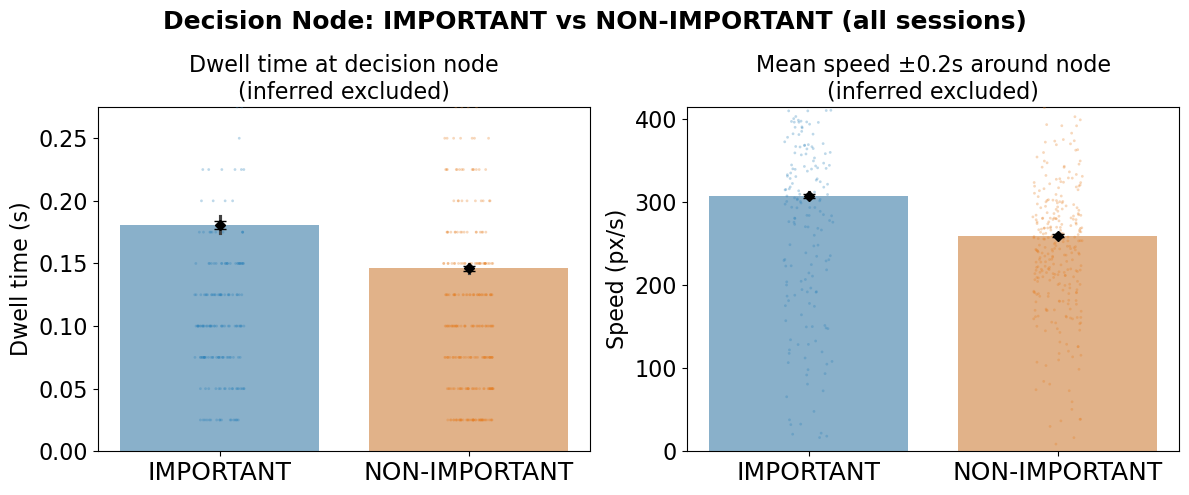

In [69]:
# ── Plot 1: Dwell time and speed — IMPORTANT vs NON-IMPORTANT ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {'important': '#2980b9', 'non_important': '#e67e22'}
order   = ['important', 'non_important']

for ax, col, ylabel, title, src_df in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time at decision node\n(inferred excluded)',
     visits_clean),
    (axes[1], 'mean_speed_pxs', 'Speed (px/s)',
     f'Mean speed \u00b1{VEL_WIN_S:.1f}s around node\n(inferred excluded)',
     visits_clean),
]:
    plot_df = src_df[src_df[col].notna()].copy()

    sns.barplot(
        data=plot_df, x='classification', y=col, order=order,
        palette=palette, ax=ax, alpha=0.6, hue='classification'
    )
    sns.stripplot(
        data=plot_df.sample(min(500, len(plot_df)), random_state=0),
        x='classification', y=col, order=order,
        palette=palette, size=2, alpha=0.3, jitter=True, ax=ax, hue='classification'
    )
    for xi, cls in enumerate(order):
        vals = plot_df[plot_df['classification'] == cls][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=5, capsize=4, zorder=10, label='mean\u00b1SEM')

    ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=18)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.9))
    ax.tick_params(axis='y', labelsize=16)   # set font size AFTER ylim so ticks are correct

fig.suptitle('Decision Node: IMPORTANT vs NON-IMPORTANT (all sessions)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


Counts per group (all visits, including inferred):
_cls_inf
important\n(real)            11182
important\n(inferred)         2812
non_important\n(real)        17658
non_important\n(inferred)    15011
Name: count, dtype: int64


/tmp/ipykernel_669586/1279387269.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMP\n(real)', 'IMP\n(inferred)',
/tmp/ipykernel_669586/1279387269.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMP\n(real)', 'IMP\n(inferred)',


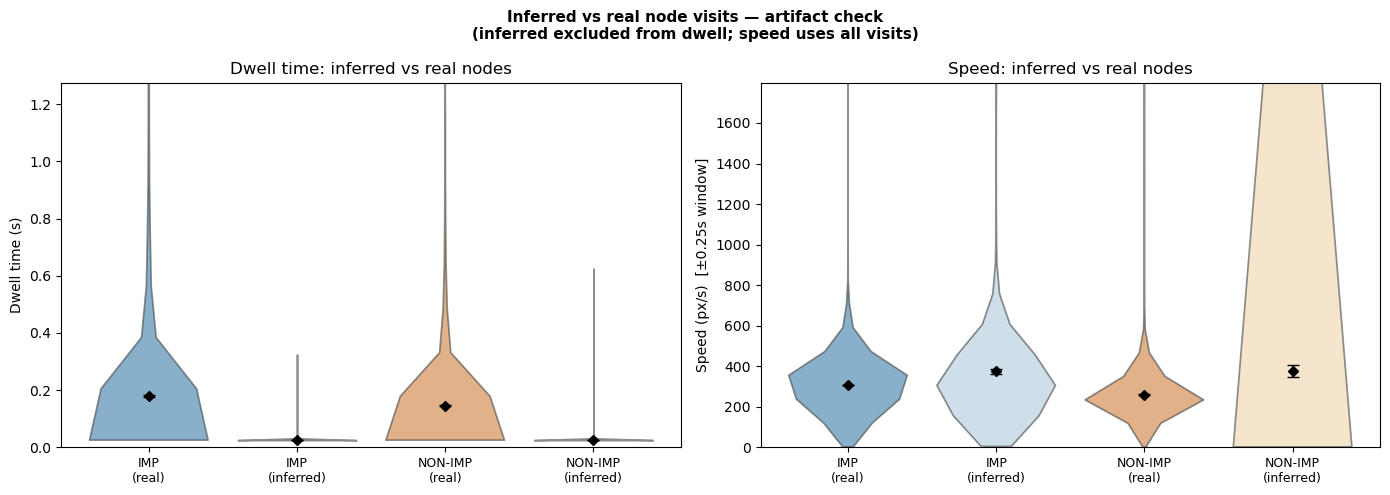


=== Dwell time (mean / median / sem / n) by classification × inferred ===
                              mean  median     sem  count
classification is_inferred                               
important      False        0.1807   0.125  0.0035  11182
               True         0.0259   0.025  0.0002   2812
non_important  False        0.1460   0.100  0.0018  17658
               True         0.0261   0.025  0.0001  15011

=== Speed by classification × inferred ===
                              mean  median    sem  count
classification is_inferred                              
important      False        307.20  301.71   2.23  11182
               True         374.97  304.75  11.48   2812
non_important  False        259.55  248.58   1.61  17658
               True         374.82  264.70  28.74  15011


In [70]:
# ── Plot: Inferred vs real split — artifact check ──────────────────────────────
# Uses the full `visits` (before inferred exclusion) to show the artifact.
# All other analyses below use visits_clean = visits[~is_inferred].

order_4   = ['important\n(real)', 'important\n(inferred)',
             'non_important\n(real)', 'non_important\n(inferred)']
palette_4 = {
    'important\n(real)':         '#2980b9',
    'important\n(inferred)':     '#a9cce3',
    'non_important\n(real)':     '#e67e22',
    'non_important\n(inferred)': '#fad7a0',
}

visits_artifact = visits.copy()
visits_artifact['_cls_inf'] = (
    visits_artifact['classification'] + '\n('
    + visits_artifact['is_inferred'].map({True: 'inferred', False: 'real'}) + ')'
)

print("Counts per group (all visits, including inferred):")
print(visits_artifact['_cls_inf'].value_counts().reindex(order_4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time: inferred vs real nodes'),
    (axes[1], 'mean_speed_pxs', f'Speed (px/s)  [±{VEL_WIN_S:.2f}s window]',
     'Speed: inferred vs real nodes'),
]:
    plot_df = visits_artifact[visits_artifact[col].notna() &
                               visits_artifact['_cls_inf'].isin(order_4)].copy()
    sns.violinplot(
        data=plot_df, x='_cls_inf', y=col, order=order_4,
        palette=palette_4, inner=None, cut=0, ax=ax, alpha=0.6, hue='_cls_inf',
        legend=False,
    )
    for xi, grp in enumerate(order_4):
        vals = plot_df[plot_df['_cls_inf'] == grp][col]
        if len(vals) > 0:
            ax.errorbar(xi, vals.mean(), yerr=vals.sem() if len(vals) > 1 else 0,
                        fmt='D', color='black', ms=5, capsize=4, zorder=10)
    ax.set_xticklabels(['IMP\n(real)', 'IMP\n(inferred)',
                         'NON-IMP\n(real)', 'NON-IMP\n(inferred)'], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.995))

fig.suptitle('Inferred vs real node visits — artifact check\n'
             '(inferred excluded from dwell; speed uses all visits)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Dwell time (mean / median / sem / n) by classification × inferred ===")
print(visits_artifact.groupby(['classification', 'is_inferred'])['dwell_s']
      .agg(['mean', 'median', 'sem', 'count']).round(4))
print("\n=== Speed by classification × inferred ===")
print(visits_artifact.groupby(['classification', 'is_inferred'])['mean_speed_pxs']
      .agg(['mean', 'median', 'sem', 'count']).round(2))

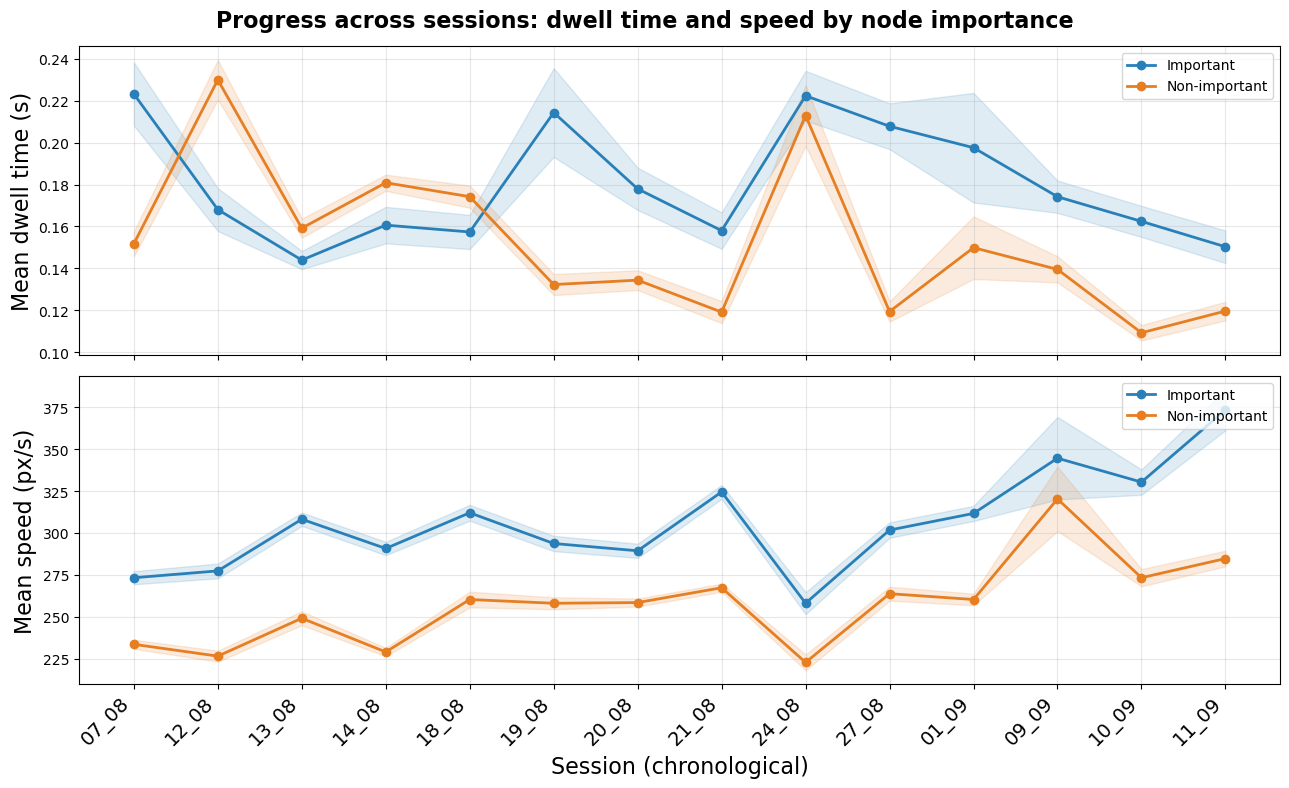

In [71]:
# ── Plot: Progress across sessions (chronological) ─────────────────────────────
# Both metrics from visits_clean (inferred excluded).
from datetime import datetime

def session_to_date(s):
    dd, mm, yyyy = s.split('_')
    return datetime(int(yyyy), int(mm), int(dd))

sessions_chron  = sorted(SESSIONS, key=session_to_date)
session_labels  = [s[:5] for s in sessions_chron]   # "DD_MM"

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
cls_style = {
    'important':     ('#2980b9', 'Important'),
    'non_important': ('#e67e22', 'Non-important'),
}

for ax, col, ylabel, src_df in [
    (axes[0], 'dwell_s',
     'Mean dwell time (s)\n(inferred excluded)',
     visits_clean),
    (axes[1], 'mean_speed_pxs',
     f'Mean speed (px/s)  [\u00b1{VEL_WIN_S:.2f}s window]\n(inferred excluded)',
     visits_clean),
]:
    for cls, (color, label) in cls_style.items():
        ys   = []
        sems = []
        for sess in sessions_chron:
            vals = src_df[(src_df['session'] == sess) &
                          (src_df['classification'] == cls)][col].dropna()
            ys.append(vals.mean() if len(vals) > 0 else np.nan)
            sems.append(vals.sem()  if len(vals) > 1 else np.nan)
        ys   = np.array(ys,   dtype=float)
        sems = np.array(sems, dtype=float)
        xs = np.arange(len(sessions_chron))
        ax.plot(xs, ys, 'o-', color=color, label=label, ms=6, linewidth=2)
        ax.fill_between(xs, ys - sems, ys + sems, color=color, alpha=0.15)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    # ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[1].set_xticks(range(len(sessions_chron)))
axes[1].set_xticklabels(session_labels, rotation=45, ha='right', fontsize=14)
axes[1].set_xlabel('Session (chronological)', fontsize=16)
axes[0].set_ylabel('Mean dwell time (s)', fontsize=16)
axes[1].set_ylabel('Mean speed (px/s)', fontsize=16)

fig.suptitle('Progress across sessions: dwell time and speed by node importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


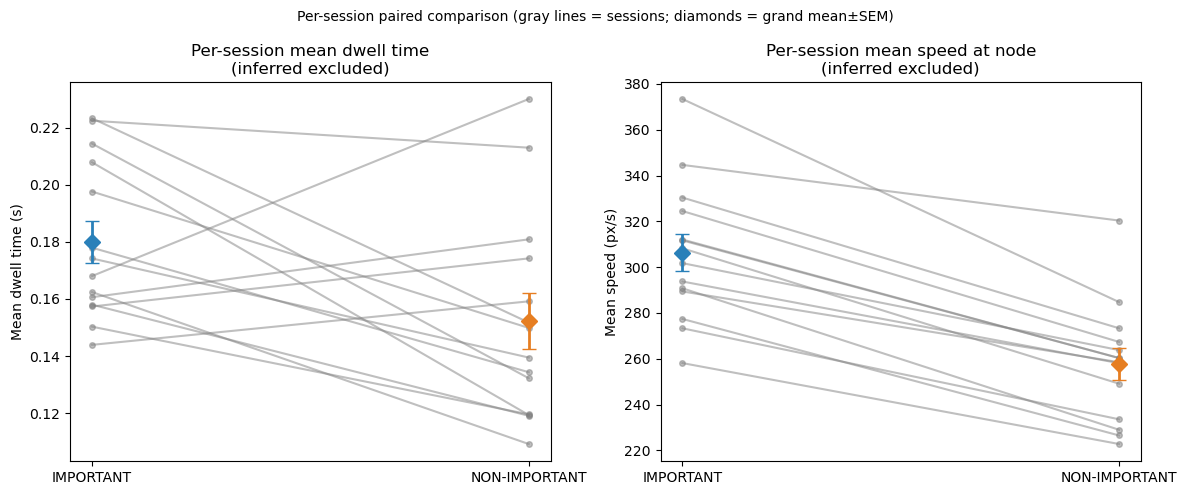

In [72]:
# ── Plot 2: Per-session mean dwell and speed (paired, to see consistency) ─────
# Both metrics from visits_clean (inferred excluded).
sess_means_dwell = (
    visits_clean.groupby(['session', 'classification'])[['dwell_s']]
    .mean().reset_index()
)
sess_means_speed = (
    visits_clean.groupby(['session', 'classification'])[['mean_speed_pxs']]
    .mean().reset_index()
)
sess_means = sess_means_dwell.merge(sess_means_speed, on=['session', 'classification'], how='outer')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)',
     'Per-session mean dwell time\n(inferred excluded)'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',
     'Per-session mean speed at node\n(inferred excluded)'),
]:
    for sess in SESSIONS:
        sub = sess_means[sess_means['session'] == sess].set_index('classification')
        if 'important' in sub.index and 'non_important' in sub.index:
            ax.plot(
                ['IMPORTANT', 'NON-IMPORTANT'],
                [sub.loc['important', col], sub.loc['non_important', col]],
                'o-', color='gray', alpha=0.5, ms=4,
            )
    for xi, cls in enumerate(['important', 'non_important']):
        vals = sess_means[sess_means['classification'] == cls][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=palette[cls], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # ax.set_ylim(bottom=0)

fig.suptitle('Per-session paired comparison (gray lines = sessions; diamonds = grand mean\u00b1SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()


---
## Within-patch dwelling: Stay vs Leave

For each visit to a **within-patch IMPORTANT node** (L10, L11, R10, R11), classify whether the mouse is:
- **Cycling** (staying in patch): came from one patch child → went to the other patch child  
- **Leaving** (exiting patch): came from a patch child → went toward the parent (= the rest of the tree)  
- **Arriving**: came from the parent direction (skip for this analysis)

Question: is dwell time longer (and/or speed lower) at the within-patch node when the mouse is about to leave the patch?

In [73]:
# ── Classify within-patch node visits: altering, leaving, or arriving ──────────
wp_visits = visits_clean[visits_clean['is_within_patch']].copy()

def classify_wp_visit(row) -> str | None:
    node      = row['node']
    came_from = row['came_from']
    went_to   = row['went_to']
    if node not in WITHIN_PATCH_INFO:
        return None
    info     = WITHIN_PATCH_INFO[node]
    parent   = info['parent']
    patch_ch = info['patch_children']

    if came_from == parent:
        return 'arriving'
    if came_from in patch_ch:
        if went_to in patch_ch:
            return 'altering'
        if went_to == parent:
            return 'leaving'
    return 'other'

wp_visits = wp_visits.copy()
wp_visits['wp_decision'] = wp_visits.apply(classify_wp_visit, axis=1)

# wp_visits_speed is a copy of wp_visits (both inferred-excluded)
# wp_visits_speed = visits[visits['is_within_patch']].copy()
# wp_visits_speed['wp_decision'] = wp_visits_speed.apply(classify_wp_visit, axis=1)
wp_visits_speed = wp_visits.copy()

print("Within-patch node visit types (inferred excluded):")
print(wp_visits['wp_decision'].value_counts())
print("\nBreakdown by node:")
print(wp_visits.groupby(['node', 'wp_decision']).size().unstack(fill_value=0))


Within-patch node visit types (inferred excluded):
wp_decision
altering    4111
arriving    2128
leaving     1851
other        219
Name: count, dtype: int64

Breakdown by node:
wp_decision  altering  arriving  leaving  other
node                                           
L10               905       418      313     38
L11               881       495      511     31
R10               997       506      432     39
R11              1328       709      595    111


In [74]:
# ── Statistics: altering vs leaving ────────────────────────────────────────────
alter_df      = wp_visits[wp_visits['wp_decision'] == 'altering']
leave_df      = wp_visits[wp_visits['wp_decision'] == 'leaving']
arrive_df     = wp_visits[wp_visits['wp_decision'] == 'arriving']
alter_df_spd  = wp_visits_speed[wp_visits_speed['wp_decision'] == 'altering']
leave_df_spd  = wp_visits_speed[wp_visits_speed['wp_decision'] == 'leaving']
arrive_df_spd = wp_visits_speed[wp_visits_speed['wp_decision'] == 'arriving']

print("=" * 60)
print("Within-patch node: ALTERING vs LEAVING comparison")
print("=" * 60)

for col, lbl, grp_a, grp_l, grp_ar in [
    ('dwell_s',        'Dwell time (s)',                   alter_df,     leave_df,     arrive_df),
    ('mean_speed_pxs', 'Speed (px/s)  [inferred excluded]', alter_df_spd, leave_df_spd, arrive_df_spd),
]:
    ca = grp_a[col].dropna()
    la = grp_l[col].dropna()
    aa = grp_ar[col].dropna()
    print(f"\n{lbl}")
    print(f"  Altering  n={len(ca):4d}  mean={ca.mean():.4f}  median={ca.median():.4f}  sem={ca.sem():.4f}")
    print(f"  Leaving   n={len(la):4d}  mean={la.mean():.4f}  median={la.median():.4f}  sem={la.sem():.4f}")
    print(f"  Arriving  n={len(aa):4d}  mean={aa.mean():.4f}  median={aa.median():.4f}  sem={aa.sem():.4f}")
    if len(ca) > 1 and len(la) > 1:
        u, p = stats.mannwhitneyu(ca, la, alternative='two-sided')
        print(f"  Mann-Whitney U={u:.0f}, p={p:.4g}")


Within-patch node: ALTERING vs LEAVING comparison

Dwell time (s)
  Altering  n=4111  mean=0.1639  median=0.1250  sem=0.0032
  Leaving   n=1851  mean=0.1465  median=0.0750  sem=0.0095
  Arriving  n=2128  mean=0.2098  median=0.1250  sem=0.0116
  Mann-Whitney U=5627664, p=1.224e-196

Speed (px/s)  [inferred excluded]
  Altering  n=4111  mean=325.4207  median=321.2789  sem=3.5959
  Leaving   n=1851  mean=258.2764  median=242.1966  sem=6.7180
  Arriving  n=2128  mean=256.4780  median=254.4080  sem=3.0402
  Mann-Whitney U=5452163, p=4.115e-158


/tmp/ipykernel_669586/1147952488.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)
/tmp/ipykernel_669586/1147952488.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)


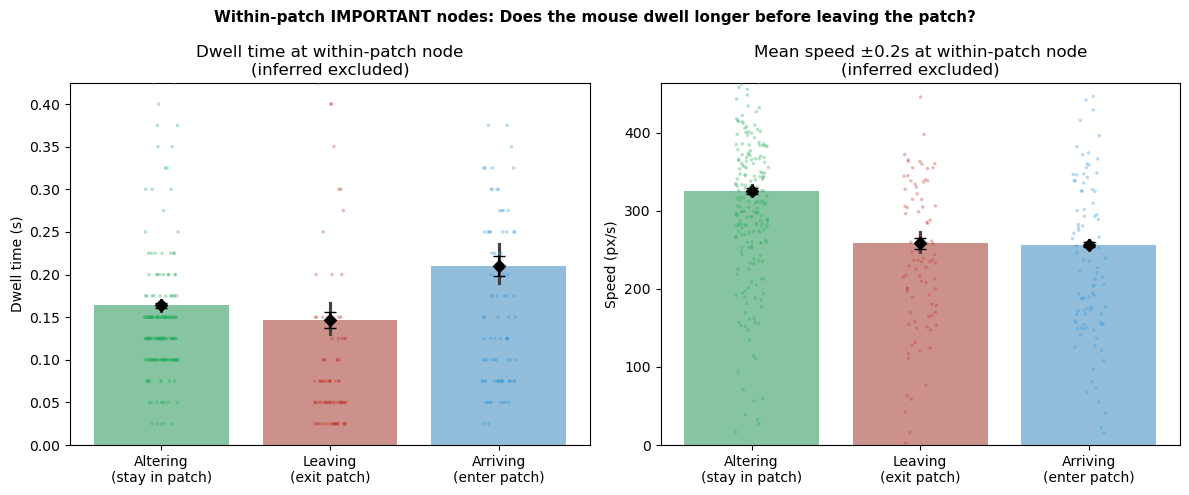

In [75]:
# ── Plot 3: Within-patch node — altering vs leaving ────────────────────────────
wp_plot_df       = wp_visits[wp_visits['wp_decision'].isin(['altering', 'leaving', 'arriving'])].copy()
wp_plot_df_speed = wp_visits_speed[wp_visits_speed['wp_decision'].isin(['altering', 'leaving', 'arriving'])].copy()
wp_palette = {'altering': '#27ae60', 'leaving': '#c0392b', 'arriving': '#3498db'}
wp_order   = ['altering', 'leaving', 'arriving']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title, plot_src in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time at within-patch node\n(inferred excluded)',
     wp_plot_df),
    (axes[1], 'mean_speed_pxs', 'Speed (px/s)',
     f'Mean speed \u00b1{VEL_WIN_S:.1f}s at within-patch node\n(inferred excluded)',
     wp_plot_df_speed),
]:
    plot_df = plot_src[plot_src[col].notna()]
    sns.barplot(
        data=plot_df, x='wp_decision', y=col, order=wp_order,
        palette=wp_palette, ax=ax, alpha=0.6, hue='wp_decision'
    )
    sns.stripplot(
        data=plot_df.sample(min(400, len(plot_df)), random_state=42),
        x='wp_decision', y=col, order=wp_order,
        palette=wp_palette, size=2.5, alpha=0.35, jitter=True, ax=ax, hue='wp_decision'
    )
    for xi, dec in enumerate(wp_order):
        vals = plot_df[plot_df['wp_decision'] == dec][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=6, capsize=4, zorder=10)
    ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.95))

fig.suptitle('Within-patch IMPORTANT nodes: Does the mouse dwell longer before leaving the patch?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


Counts (within-patch, all visits including inferred):
_dec_inf
altering\n(real)        4111
altering\n(inferred)     245
leaving\n(real)         1851
leaving\n(inferred)     1121
arriving\n(real)        2128
arriving\n(inferred)     861
Name: count, dtype: int64


/tmp/ipykernel_669586/3631942798.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_669586/3631942798.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


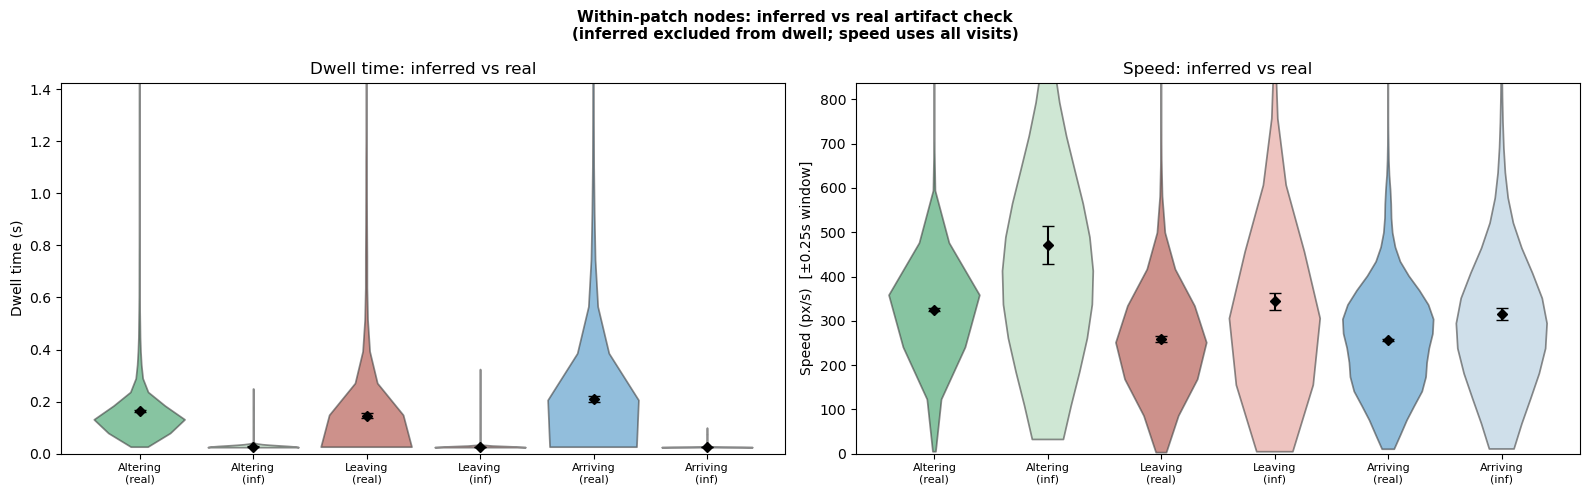


=== Dwell time by wp_decision × inferred ===
                           mean  median     sem  count
wp_decision is_inferred                               
altering    False        0.1639   0.125  0.0032   4111
            True         0.0272   0.025  0.0012    245
arriving    False        0.2098   0.125  0.0116   2128
            True         0.0253   0.025  0.0001    861
leaving     False        0.1465   0.075  0.0095   1851
            True         0.0261   0.025  0.0005   1121

=== Speed by wp_decision × inferred ===
                           mean  median    sem  count
wp_decision is_inferred                              
altering    False        325.42  321.28   3.60   4111
            True         471.04  389.67  42.75    245
arriving    False        256.48  254.41   3.04   2128
            True         315.08  284.05  13.55    861
leaving     False        258.28  242.20   6.72   1851
            True         343.71  276.00  19.75   1121


In [76]:
# ── Within-patch: inferred vs real artifact check ─────────────────────────────
# Derive wp_visits from the FULL `visits` (including inferred) for comparison.
# classify_wp_visit is defined above; is_within_patch flag is set in process_session.

wp_artifact = visits[visits['is_within_patch']].copy()
wp_artifact['wp_decision'] = wp_artifact.apply(classify_wp_visit, axis=1)
wp_artifact = wp_artifact[
    wp_artifact['wp_decision'].isin(['altering', 'leaving', 'arriving'])
].copy()
wp_artifact['_dec_inf'] = (
    wp_artifact['wp_decision'] + '\n('
    + wp_artifact['is_inferred'].map({True: 'inferred', False: 'real'}) + ')'
)

order_wp6 = [
    'altering\n(real)', 'altering\n(inferred)',
    'leaving\n(real)',  'leaving\n(inferred)',
    'arriving\n(real)', 'arriving\n(inferred)',
]
palette_wp6 = {
    'altering\n(real)':     '#27ae60',
    'altering\n(inferred)': '#a9dfb4',
    'leaving\n(real)':      '#c0392b',
    'leaving\n(inferred)':  '#f1948a',
    'arriving\n(real)':     '#3498db',
    'arriving\n(inferred)': '#a9cce3',
}

print("Counts (within-patch, all visits including inferred):")
print(wp_artifact['_dec_inf'].value_counts().reindex(order_wp6))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time: inferred vs real'),
    (axes[1], 'mean_speed_pxs', f'Speed (px/s)  [±{VEL_WIN_S:.2f}s window]',
     'Speed: inferred vs real'),
]:
    plot_df = wp_artifact[
        wp_artifact[col].notna() & wp_artifact['_dec_inf'].isin(order_wp6)
    ].copy()
    sns.violinplot(
        data=plot_df, x='_dec_inf', y=col, order=order_wp6,
        palette=palette_wp6, inner=None, cut=0, ax=ax, alpha=0.6,
        hue='_dec_inf', legend=False,
    )
    for xi, grp in enumerate(order_wp6):
        vals = plot_df[plot_df['_dec_inf'] == grp][col]
        if len(vals) > 0:
            ax.errorbar(xi, vals.mean(), yerr=vals.sem() if len(vals) > 1 else 0,
                        fmt='D', color='black', ms=5, capsize=4, zorder=10)
    ax.set_xticklabels(
        ['Altering\n(real)', 'Altering\n(inf)',
         'Leaving\n(real)',  'Leaving\n(inf)',
         'Arriving\n(real)', 'Arriving\n(inf)'],
        fontsize=8,
    )
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.995))

fig.suptitle('Within-patch nodes: inferred vs real artifact check\n'
             '(inferred excluded from dwell; speed uses all visits)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Dwell time by wp_decision × inferred ===")
print(wp_artifact.groupby(['wp_decision', 'is_inferred'])['dwell_s']
      .agg(['mean', 'median', 'sem', 'count']).round(4))
print("\n=== Speed by wp_decision × inferred ===")
print(wp_artifact.groupby(['wp_decision', 'is_inferred'])['mean_speed_pxs']
      .agg(['mean', 'median', 'sem', 'count']).round(2))

/tmp/ipykernel_669586/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_669586/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_669586/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_669586/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)


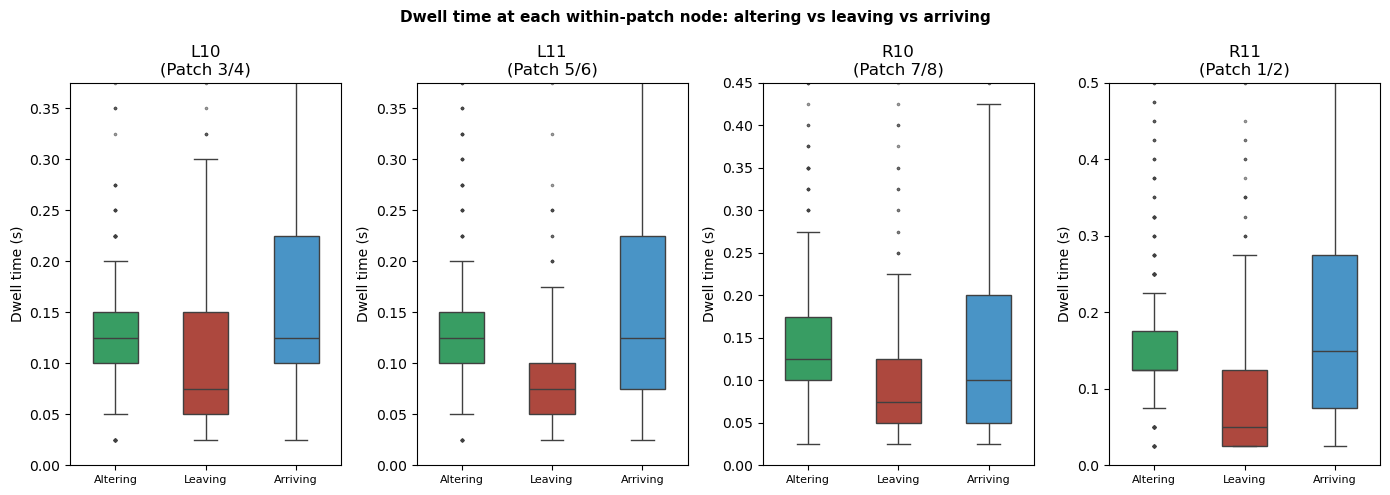

In [77]:
# ── Plot 4: Per-node breakdown — altering vs leaving dwell time ────────────────
fig, axes = plt.subplots(1, len(WITHIN_PATCH_NODES), figsize=(14, 5), sharey=False)

for ax, node in zip(axes, sorted(WITHIN_PATCH_NODES)):
    node_df = wp_plot_df[wp_plot_df['node'] == node]
    if node_df.empty:
        ax.set_title(node)
        continue
    info = WITHIN_PATCH_INFO[node]

    sns.boxplot(
        data=node_df[node_df['dwell_s'].notna()],
        x='wp_decision', y='dwell_s', order=wp_order,
        palette=wp_palette, ax=ax, width=0.5, hue='wp_decision', dodge=False,
        flierprops=dict(marker='.', ms=3, alpha=0.4),
    )
    patch_label = f"Patch {info['patch'][0]}/{info['patch'][1]}"
    ax.set_title(f"{node}\n({patch_label})")
    ax.set_xlabel('')
    ax.set_ylabel('Dwell time (s)')
    ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
    ax.set_ylim(bottom=0, top=node_df['dwell_s'].quantile(0.95))

fig.suptitle('Dwell time at each within-patch node: altering vs leaving vs arriving',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Wilcoxon signed-rank (per-session paired means):
  Dwell time: W=18, p=0.02954  (n=14 sessions)
  Speed: W=1, p=0.0002441  (n=14 sessions)


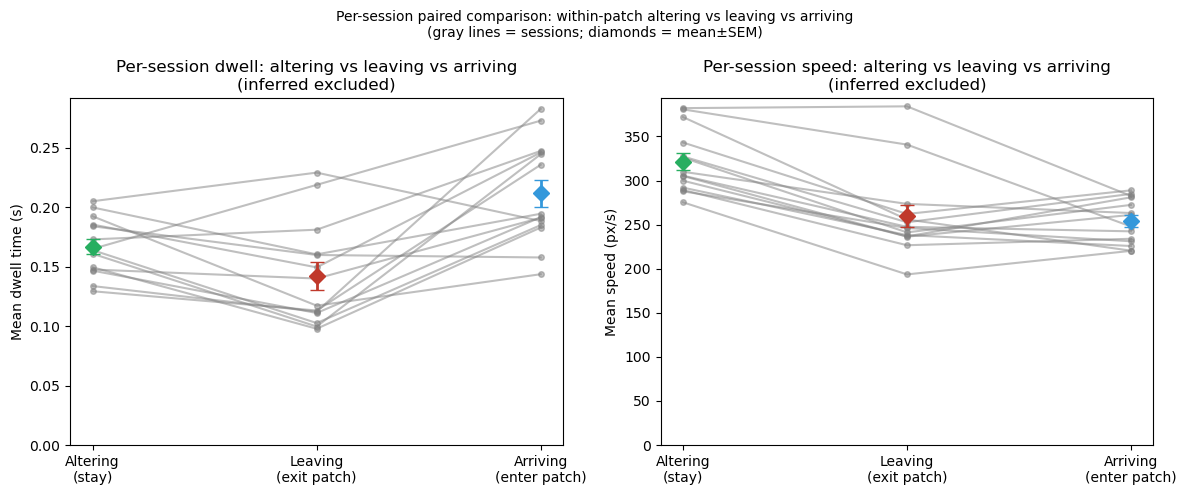

In [78]:
# ── Per-session paired test: within-patch altering vs leaving ──────────────────
_wp_dec_filter = ['altering', 'leaving', 'arriving']
sess_wp_means_dwell = (
    wp_visits[wp_visits['wp_decision'].isin(_wp_dec_filter)]
    .groupby(['session', 'wp_decision'])[['dwell_s']]
    .mean().reset_index()
)
sess_wp_means_speed = (
    wp_visits_speed[wp_visits_speed['wp_decision'].isin(_wp_dec_filter)]
    .groupby(['session', 'wp_decision'])[['mean_speed_pxs']]
    .mean().reset_index()
)
sess_wp_means = sess_wp_means_dwell.merge(sess_wp_means_speed, on=['session', 'wp_decision'], how='outer')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)',
     'Per-session dwell: altering vs leaving vs arriving\n(inferred excluded)'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',
     'Per-session speed: altering vs leaving vs arriving\n(inferred excluded)'),
]:
    for sess in SESSIONS:
        sub = sess_wp_means[sess_wp_means['session'] == sess].set_index('wp_decision')
        if 'altering' in sub.index and 'leaving' in sub.index and 'arriving' in sub.index:
            ax.plot(
                ['Altering', 'Leaving', 'Arriving'],
                [sub.loc['altering', col], sub.loc['leaving', col], sub.loc['arriving', col]],
                'o-', color='gray', alpha=0.5, ms=4,
            )
    for xi, dec in enumerate(['altering', 'leaving', 'arriving']):
        vals = sess_wp_means[sess_wp_means['wp_decision'] == dec][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=wp_palette[dec], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Altering\n(stay)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)

# Wilcoxon signed-rank test on per-session paired means
print("Wilcoxon signed-rank (per-session paired means):")
for col, lbl in [('dwell_s', 'Dwell time'), ('mean_speed_pxs', 'Speed')]:
    paired = []
    for sess in SESSIONS:
        sub = sess_wp_means[sess_wp_means['session'] == sess].set_index('wp_decision')
        if 'altering' in sub.index and 'leaving' in sub.index and 'arriving' in sub.index:
            paired.append((sub.loc['altering', col], sub.loc['leaving', col], sub.loc['arriving', col]))
    if len(paired) >= 4:
        al_vals, lv_vals, ar_vals = zip(*[p for p in paired if not any(np.isnan(x) for x in p)])
        stat, p = stats.wilcoxon(al_vals, lv_vals)
        print(f"  {lbl}: W={stat:.0f}, p={p:.4g}  (n={len(al_vals)} sessions)")

fig.suptitle('Per-session paired comparison: within-patch altering vs leaving vs arriving\n'
             '(gray lines = sessions; diamonds = mean\u00b1SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()


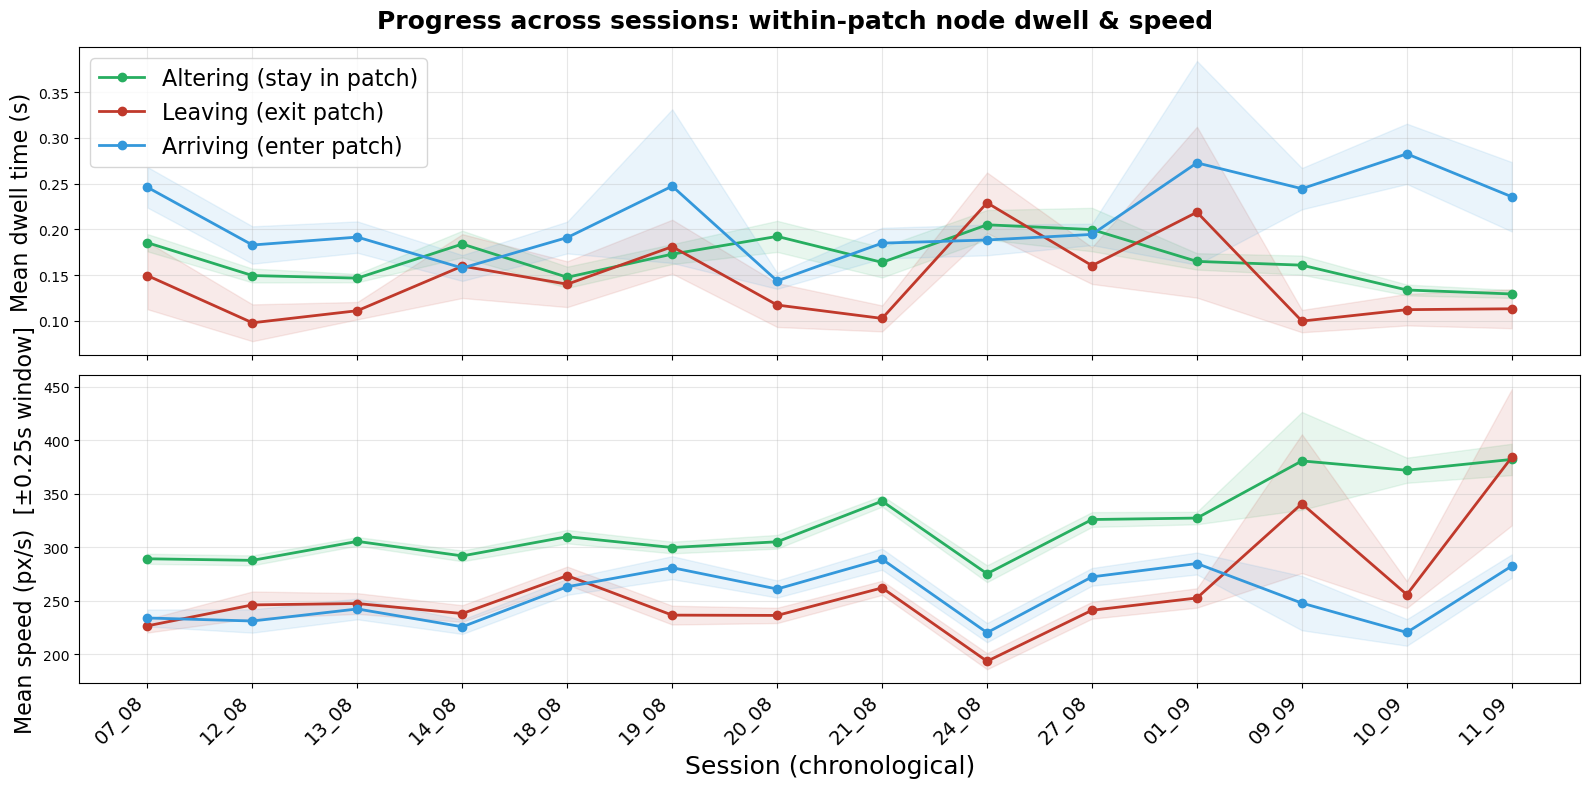

In [79]:
# ── Progress across sessions: within-patch node dwell & speed ──────────────────
wp_progress_style = {
    'altering': ('#27ae60', 'Altering (stay in patch)'),
    'leaving':  ('#c0392b', 'Leaving (exit patch)'),
    'arriving': ('#3498db', 'Arriving (enter patch)'),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, col, ylabel, wp_src in [
    (axes[0], 'dwell_s',
     'Mean dwell time (s)',
     wp_visits),
    (axes[1], 'mean_speed_pxs',
     f'Mean speed (px/s)  [\u00b1{VEL_WIN_S:.2f}s window]',
     wp_visits_speed),
]:
    wp_progress_df = wp_src[wp_src['wp_decision'].isin(['altering', 'leaving', 'arriving'])].copy()
    for dec, (color, label) in wp_progress_style.items():
        ys, sems = [], []
        for sess in sessions_chron:
            vals = wp_progress_df[
                (wp_progress_df['session'] == sess) &
                (wp_progress_df['wp_decision'] == dec)
            ][col].dropna()
            ys.append(vals.mean() if len(vals) > 0 else np.nan)
            sems.append(vals.sem()  if len(vals) > 1 else np.nan)
        ys   = np.array(ys,   dtype=float)
        sems = np.array(sems, dtype=float)
        xs   = np.arange(len(sessions_chron))
        ax.plot(xs, ys, 'o-', color=color, label=label, ms=6, linewidth=2)
        ax.fill_between(xs, ys - sems, ys + sems, color=color, alpha=0.1)
    ax.set_ylabel(ylabel, fontsize=16)
    
    # ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='upper left', fontsize=16, framealpha=0.8)
axes[1].set_xticks(range(len(sessions_chron)))
axes[1].set_xticklabels(session_labels, rotation=45, ha='right', fontsize=14)
axes[1].set_xlabel('Session (chronological)', fontsize=18)

fig.suptitle('Progress across sessions: within-patch node dwell & speed',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Sometimes-important nodes: toward-reward vs away-from-reward

The 16 **sometimes-important** nodes each sit at the boundary of an arm leading to a single reward port. At these nodes the mouse always faces the same structural choice:
- **Toward reward**: move closer (by hop count) to the nearest reward — going into the local arm
- **Away from reward**: move farther from reward — heading back to the main trunk

The old "important" direction (arrived from the dead-end side of the arm, both forward branches reach reward) is **away_from_reward**: one branch leads to the local reward, the other leads back to the main trunk where many rewards are accessible, but all via the same single upward path — not a true bifurcation. Both approach directions are therefore treated as **non_important** in the main analysis.

This section analyses whether the mouse's dwell time and speed at these nodes differ depending on whether it is heading toward or away from the local reward port, using the same hop-distance criterion as `turn_analysis.ipynb`.

Sometimes-important nodes: 16 nodes
Total visits to these nodes (real, non-inferred): 17034
direction
toward_reward       9471
away_from_reward    6726
Name: count, dtype: int64

SOMETIMES-IMPORTANT nodes — toward-reward vs away-from-reward

Dwell time (s)
  toward_reward     n= 9471  mean=0.1292  median=0.1000  sem=0.0014
  away_from_reward  n= 6726  mean=0.1387  median=0.1000  sem=0.0026
  Mann-Whitney U=33423238, p=6.739e-08

Speed (px/s)  [inferred excluded]
  toward_reward     n= 9471  mean=263.3858  median=254.5706  sem=1.9427
  away_from_reward  n= 6726  mean=274.2396  median=255.0554  sem=3.0559
  Mann-Whitney U=31505860, p=0.2392


/tmp/ipykernel_669586/31446003.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward\nReward', 'Away from\nReward'], fontsize=10)
/tmp/ipykernel_669586/31446003.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward\nReward', 'Away from\nReward'], fontsize=10)


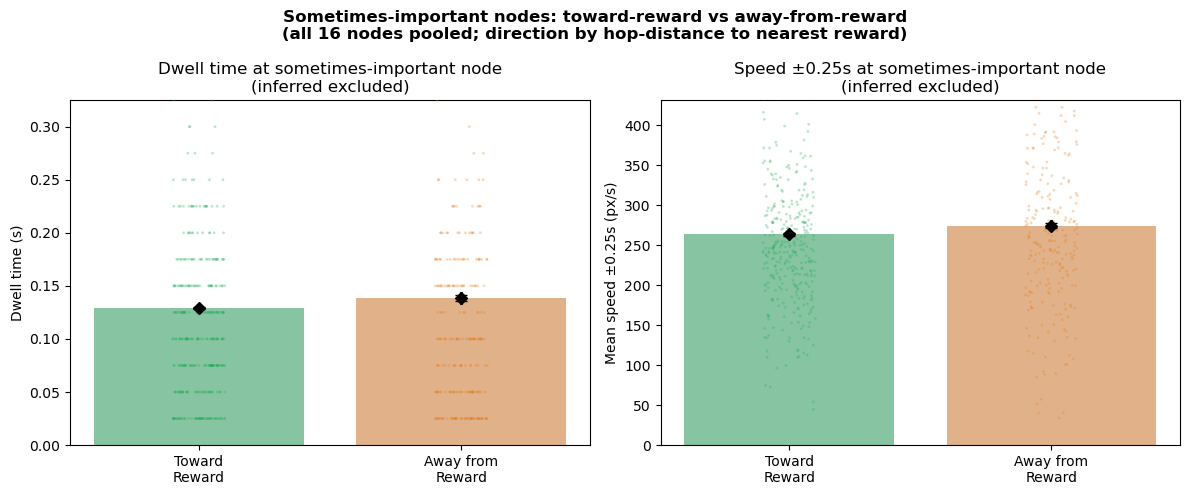

Wilcoxon signed-rank (Mean dwell time (s)): W=18, p=0.02954  (n=14 sessions)
Wilcoxon signed-rank (Mean speed (px/s)): W=21, p=0.04944  (n=14 sessions)


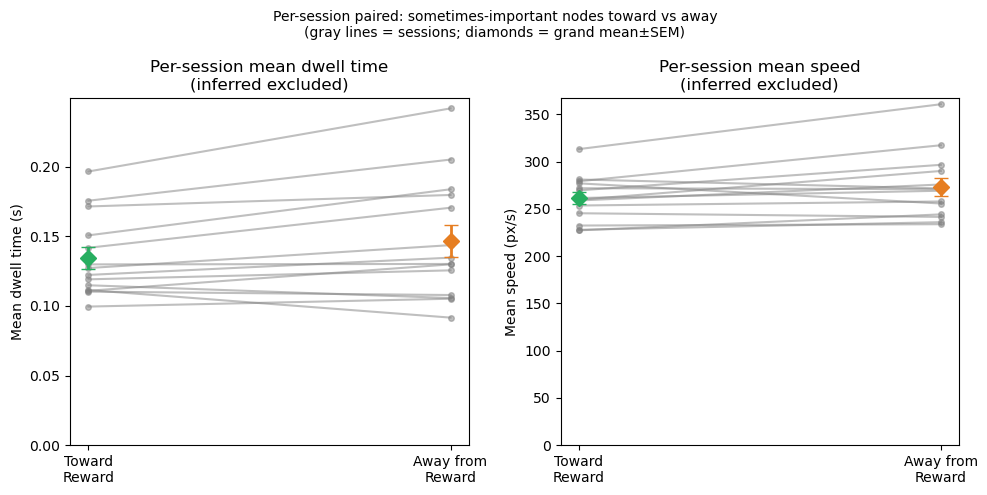

In [80]:
# ── Sometimes-important nodes: toward-reward vs away-from-reward ───────────────
si_visits = visits_clean[visits_clean['node'].isin(sometimes_imp)].copy()

print(f"Sometimes-important nodes: {len(sometimes_imp)} nodes")
print(f"Total visits to these nodes (real, non-inferred): {len(si_visits)}")

# Label each visit via hop-distance: d(went_to) vs d(came_from)
def _toward_away(row):
    d_came = min_rwd_dist.get(row['came_from'], float('inf'))
    d_went = min_rwd_dist.get(row['went_to'],   float('inf')) if pd.notna(row['went_to']) else float('inf')
    if d_went < d_came:   return 'toward_reward'
    if d_went > d_came:   return 'away_from_reward'
    return None   # neutral / ambiguous — drop

si_visits['direction'] = si_visits.apply(_toward_away, axis=1)
si_visits = si_visits[si_visits['direction'].notna()].copy()

# si_visits_speed is a copy of si_visits (both inferred-excluded)
# si_visits_speed = visits[visits['node'].isin(sometimes_imp)].copy()
# si_visits_speed['direction'] = si_visits_speed.apply(_toward_away, axis=1)
# si_visits_speed = si_visits_speed[si_visits_speed['direction'].notna()].copy()

si_visits_speed = si_visits.copy()

print(si_visits['direction'].value_counts())
print()

# ── Overall statistics ─────────────────────────────────────────────────────────
print("=" * 65)
print("SOMETIMES-IMPORTANT nodes — toward-reward vs away-from-reward")
print("=" * 65)

si_toward      = si_visits[si_visits['direction'] == 'toward_reward']
si_away        = si_visits[si_visits['direction'] == 'away_from_reward']
si_toward_spd  = si_visits_speed[si_visits_speed['direction'] == 'toward_reward']
si_away_spd    = si_visits_speed[si_visits_speed['direction'] == 'away_from_reward']

for col, lbl, grp_t, grp_a in [
    ('dwell_s',        'Dwell time (s)',                  si_toward,    si_away),
    ('mean_speed_pxs', 'Speed (px/s)  [inferred excluded]', si_toward_spd, si_away_spd),
]:
    t = grp_t[col].dropna()
    a = grp_a[col].dropna()
    print(f"\n{lbl}")
    print(f"  toward_reward     n={len(t):5d}  mean={t.mean():.4f}  median={t.median():.4f}  sem={t.sem():.4f}")
    print(f"  away_from_reward  n={len(a):5d}  mean={a.mean():.4f}  median={a.median():.4f}  sem={a.sem():.4f}")
    if len(t) > 1 and len(a) > 1:
        u, p = stats.mannwhitneyu(t, a, alternative='two-sided')
        print(f"  Mann-Whitney U={u:.0f}, p={p:.4g}")

# ── Overall violin plot ────────────────────────────────────────────────────────
si_palette = {'toward_reward': '#27ae60', 'away_from_reward': '#e67e22'}
si_order   = ['toward_reward', 'away_from_reward']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title, si_src in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time at sometimes-important node\n(inferred excluded)',
     si_visits),
    (axes[1], 'mean_speed_pxs', f'Mean speed \u00b1{VEL_WIN_S:.2f}s (px/s)',
     f'Speed \u00b1{VEL_WIN_S:.2f}s at sometimes-important node\n(inferred excluded)',
     si_visits_speed),
]:
    plot_df = si_src[si_src[col].notna()]
    sns.barplot(
        data=plot_df, x='direction', y=col, order=si_order,
        palette=si_palette, ax=ax, alpha=0.6, hue='direction',
    )
    sns.stripplot(
        data=plot_df.sample(min(600, len(plot_df)), random_state=7),
        x='direction', y=col, order=si_order,
        palette=si_palette, size=2, alpha=0.3, jitter=True, ax=ax, hue='direction',
    )
    for xi, cls in enumerate(si_order):
        vals = plot_df[plot_df['direction'] == cls][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=6, capsize=4, zorder=10)
    ax.set_xticklabels(['Toward\nReward', 'Away from\nReward'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.95))

fig.suptitle('Sometimes-important nodes: toward-reward vs away-from-reward\n'
             '(all 16 nodes pooled; direction by hop-distance to nearest reward)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-session paired means ───────────────────────────────────────────────────
si_sess_means_dwell = (
    si_visits.groupby(['session', 'direction'])[['dwell_s']]
    .mean().reset_index()
)
si_sess_means_speed = (
    si_visits_speed.groupby(['session', 'direction'])[['mean_speed_pxs']]
    .mean().reset_index()
)
si_sess_means = si_sess_means_dwell.merge(si_sess_means_speed, on=['session', 'direction'], how='outer')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)',
     'Per-session mean dwell time\n(inferred excluded)'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',
     'Per-session mean speed\n(inferred excluded)'),
]:
    paired_toward, paired_away = [], []
    for sess in SESSIONS:
        sub = si_sess_means[si_sess_means['session'] == sess].set_index('direction')
        if 'toward_reward' in sub.index and 'away_from_reward' in sub.index:
            vt = sub.loc['toward_reward',    col]
            va = sub.loc['away_from_reward', col]
            ax.plot(['Toward\nReward', 'Away from\nReward'], [vt, va],
                    'o-', color='gray', alpha=0.5, ms=4)
            paired_toward.append(vt)
            paired_away.append(va)
    for xi, cls in enumerate(si_order):
        vals = si_sess_means[si_sess_means['direction'] == cls][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=si_palette[cls], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Toward\nReward', 'Away from\nReward'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)

    if len(paired_toward) >= 4:
        stat, p = stats.wilcoxon(paired_toward, paired_away)
        print(f"Wilcoxon signed-rank ({ylabel}): W={stat:.0f}, p={p:.4g}  "
              f"(n={len(paired_toward)} sessions)")

fig.suptitle('Per-session paired: sometimes-important nodes toward vs away\n'
             '(gray lines = sessions; diamonds = grand mean\u00b1SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()


Counts (sometimes-important, all visits including inferred):
_dir_inf
toward_reward\n(real)           9471
toward_reward\n(inferred)       5023
away_from_reward\n(real)        6726
away_from_reward\n(inferred)    7737
Name: count, dtype: int64


/tmp/ipykernel_669586/1556318097.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_669586/1556318097.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


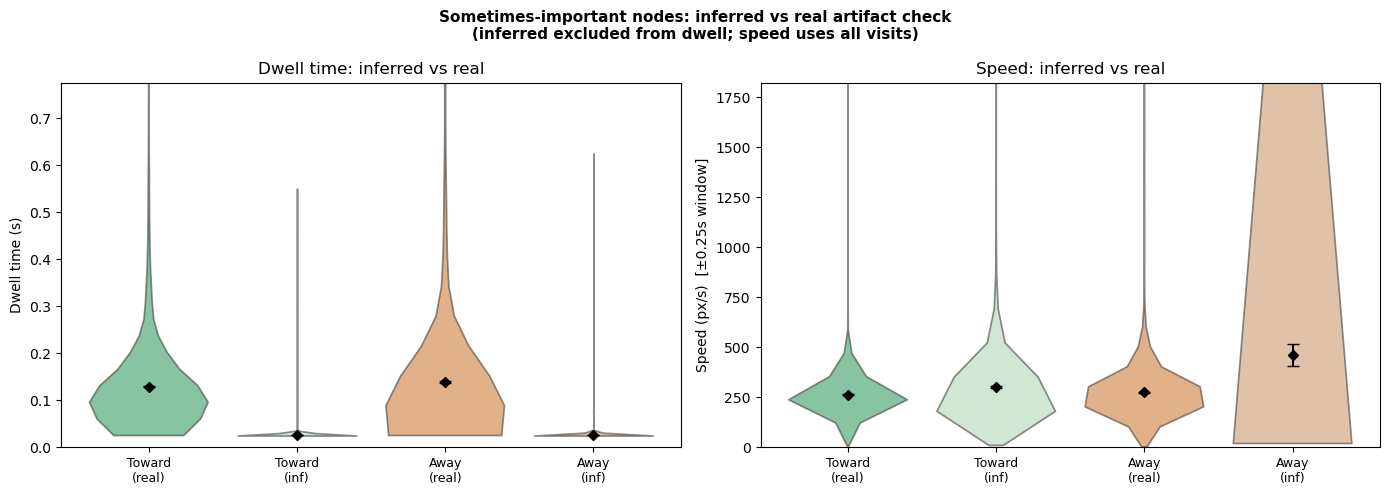


=== Dwell time by direction × inferred ===
                                mean  median     sem  count
direction        is_inferred                               
away_from_reward False        0.1387   0.100  0.0026   6726
                 True         0.0262   0.025  0.0002   7737
toward_reward    False        0.1292   0.100  0.0014   9471
                 True         0.0262   0.025  0.0003   5023

=== Speed by direction × inferred ===
                                mean  median    sem  count
direction        is_inferred                              
away_from_reward False        274.24  255.06   3.06   6726
                 True         462.78  313.55  55.49   7737
toward_reward    False        263.39  254.57   1.94   9471
                 True         301.40  241.58   6.98   5023


In [81]:
# ── Sometimes-important nodes: inferred vs real artifact check ─────────────────
# Derive si_visits from the FULL `visits` (including inferred) for comparison.
# _toward_away is defined above in this section.

si_artifact = visits[visits['node'].isin(sometimes_imp)].copy()
si_artifact['direction'] = si_artifact.apply(_toward_away, axis=1)
si_artifact = si_artifact[si_artifact['direction'].notna()].copy()
si_artifact['_dir_inf'] = (
    si_artifact['direction'] + '\n('
    + si_artifact['is_inferred'].map({True: 'inferred', False: 'real'}) + ')'
)

order_si4 = [
    'toward_reward\n(real)',    'toward_reward\n(inferred)',
    'away_from_reward\n(real)', 'away_from_reward\n(inferred)',
]
palette_si4 = {
    'toward_reward\n(real)':        '#27ae60',
    'toward_reward\n(inferred)':    '#a9dfb4',
    'away_from_reward\n(real)':     '#e67e22',
    'away_from_reward\n(inferred)': "#dc995e",
}

print("Counts (sometimes-important, all visits including inferred):")
print(si_artifact['_dir_inf'].value_counts().reindex(order_si4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time: inferred vs real'),
    (axes[1], 'mean_speed_pxs', f'Speed (px/s)  [±{VEL_WIN_S:.2f}s window]',
     'Speed: inferred vs real'),
]:
    plot_df = si_artifact[
        si_artifact[col].notna() & si_artifact['_dir_inf'].isin(order_si4)
    ].copy()
    sns.violinplot(
        data=plot_df, x='_dir_inf', y=col, order=order_si4,
        palette=palette_si4, inner=None, cut=0, ax=ax, alpha=0.6,
        hue='_dir_inf', legend=False,
    )
    for xi, grp in enumerate(order_si4):
        vals = plot_df[plot_df['_dir_inf'] == grp][col]
        if len(vals) > 0:
            ax.errorbar(xi, vals.mean(), yerr=vals.sem() if len(vals) > 1 else 0,
                        fmt='D', color='black', ms=5, capsize=4, zorder=10)
    ax.set_xticklabels(
        ['Toward\n(real)', 'Toward\n(inf)', 'Away\n(real)', 'Away\n(inf)'],
        fontsize=9,
    )
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.995))

fig.suptitle('Sometimes-important nodes: inferred vs real artifact check\n'
             '(inferred excluded from dwell; speed uses all visits)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Dwell time by direction × inferred ===")
print(si_artifact.groupby(['direction', 'is_inferred'])['dwell_s']
      .agg(['mean', 'median', 'sem', 'count']).round(4))
print("\n=== Speed by direction × inferred ===")
print(si_artifact.groupby(['direction', 'is_inferred'])['mean_speed_pxs']
      .agg(['mean', 'median', 'sem', 'count']).round(2))

/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of tic

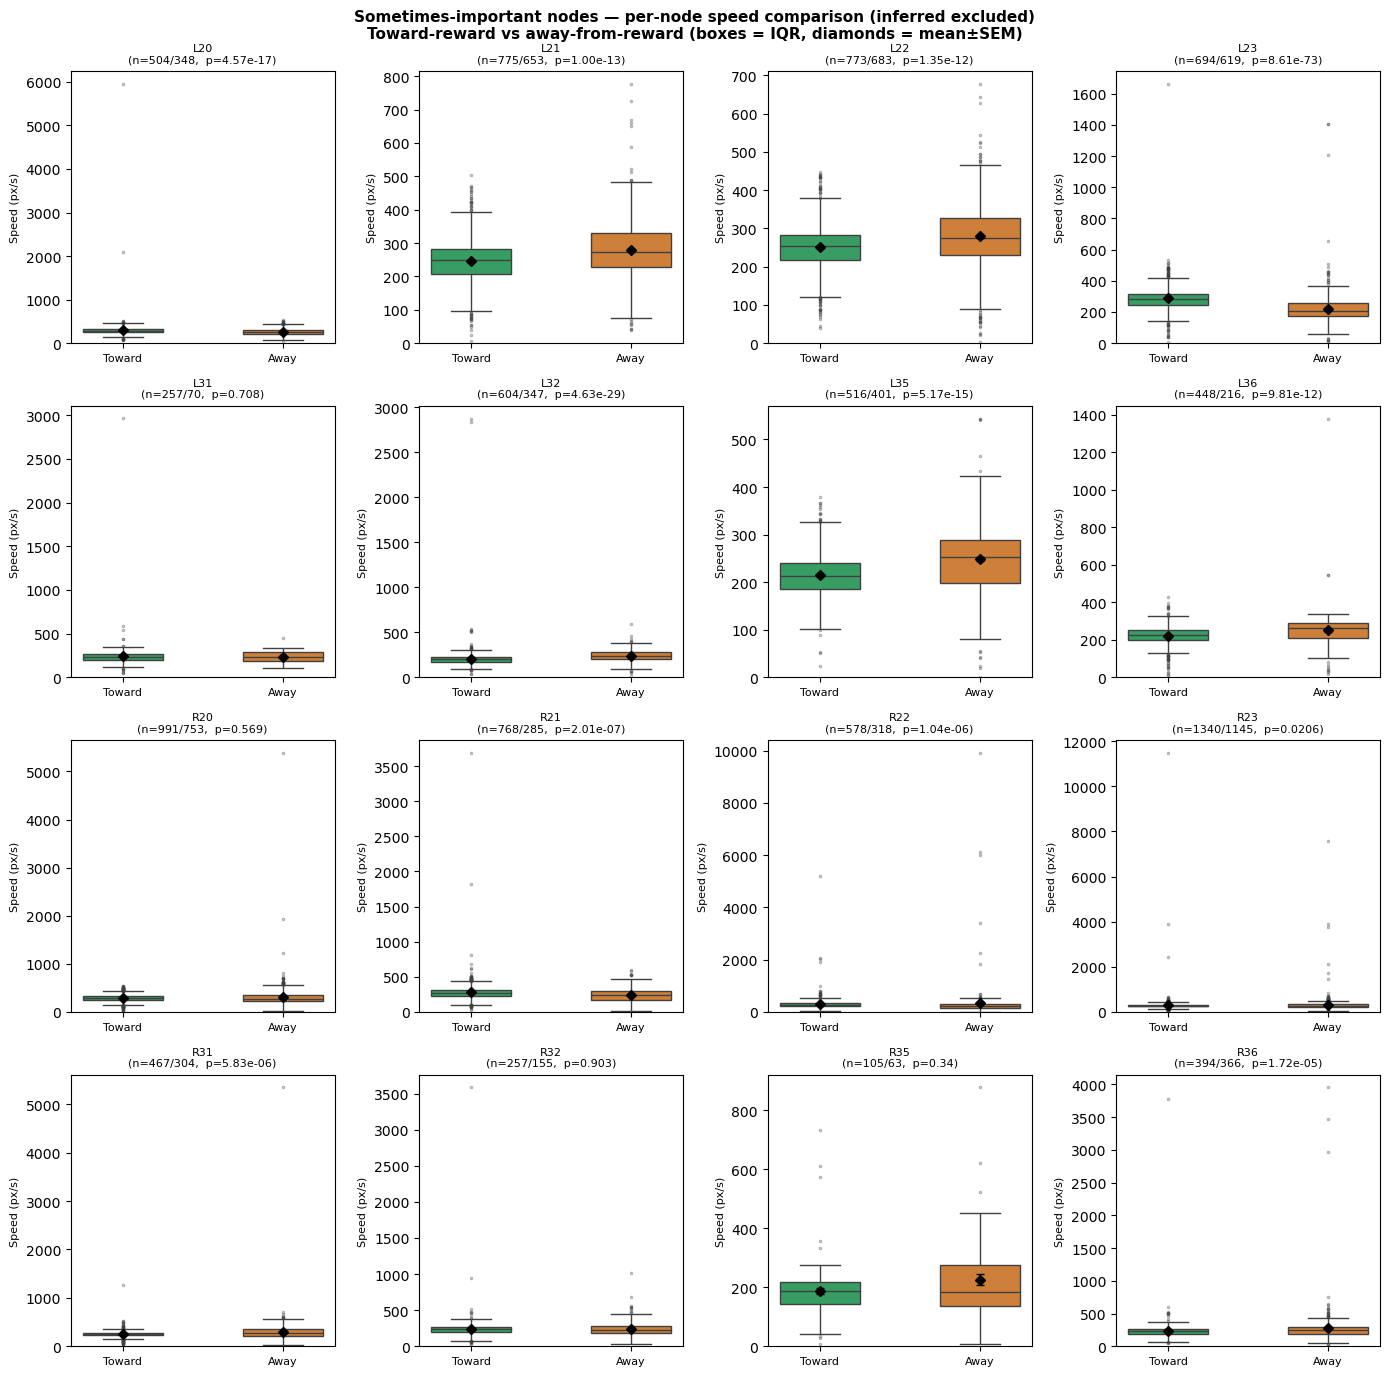

/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
/tmp/ipykernel_669586/2720723665.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of tic

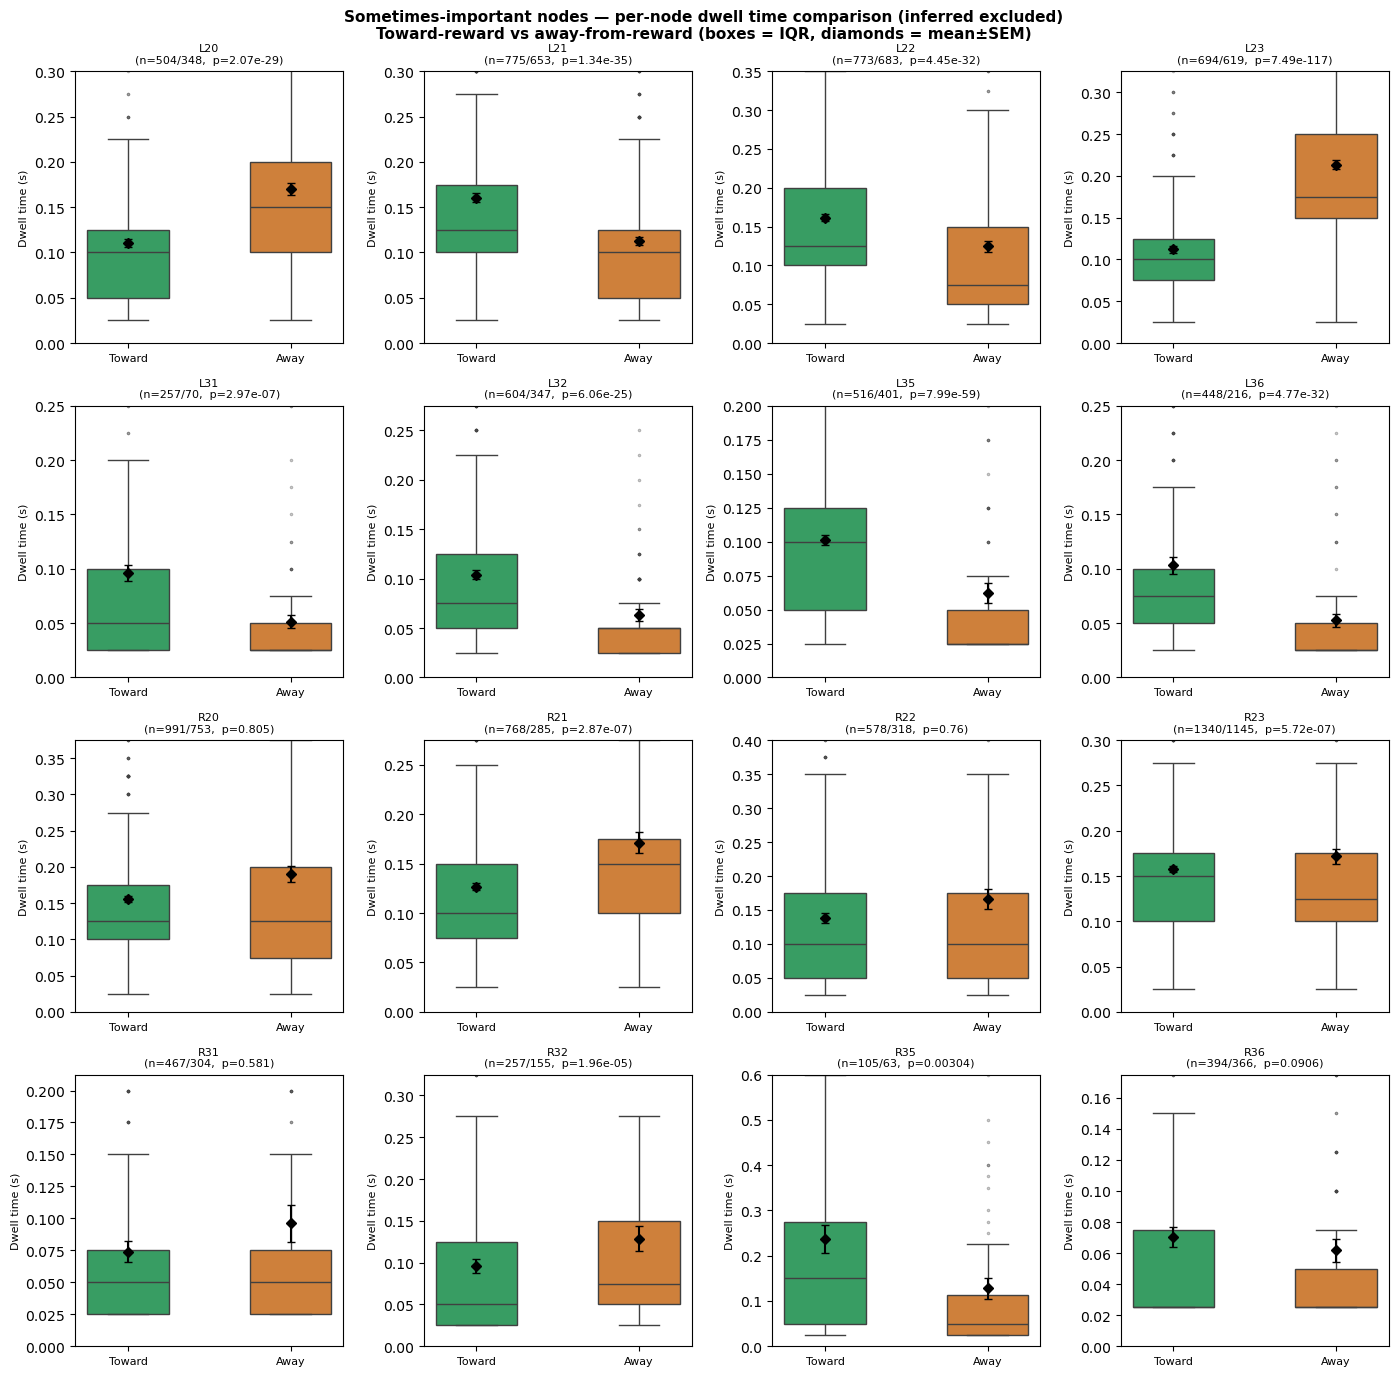

In [82]:
# ── Per-node breakdown: toward-reward vs away-from-reward ─────────────────────
nodes_sorted = sorted(sometimes_imp)
n_cols = 4
n_rows = int(np.ceil(len(nodes_sorted) / n_cols))

for metric_col, metric_label, suptitle_suffix, src_df in [
    ('mean_speed_pxs', 'Speed (px/s)',    'speed comparison (inferred excluded)',          si_visits_speed),
    ('dwell_s',        'Dwell time (s)',  'dwell time comparison (inferred excluded)',      si_visits),
]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), sharey=False)
    axes_flat  = axes.flatten()

    for ax, node in zip(axes_flat, nodes_sorted):
        node_df = src_df[src_df['node'] == node]
        if node_df.empty:
            ax.set_visible(False)
            continue

        toward_vals = node_df[node_df['direction'] == 'toward_reward'][metric_col].dropna()
        away_vals   = node_df[node_df['direction'] == 'away_from_reward'][metric_col].dropna()

        plot_df = node_df[node_df[metric_col].notna()]
        sns.boxplot(
            data=plot_df, x='direction', y=metric_col, order=si_order,
            palette=si_palette, ax=ax, width=0.5, hue='direction', dodge=False,
            flierprops=dict(marker='.', ms=3, alpha=0.4),
        )
        for xi, vals in enumerate([toward_vals, away_vals]):
            if len(vals) > 0:
                ax.errorbar(xi, vals.mean(), yerr=vals.sem() if len(vals) > 1 else 0,
                            fmt='D', color='black', ms=5, capsize=3, zorder=10)

        if len(toward_vals) > 1 and len(away_vals) > 1:
            _, p = stats.mannwhitneyu(toward_vals, away_vals, alternative='two-sided')
            pstr = f'p={p:.3g}' if p >= 0.001 else f'p={p:.2e}'
            ax.set_title(f'{node}\n(n={len(toward_vals)}/{len(away_vals)},  {pstr})', fontsize=8)
        else:
            ax.set_title(node, fontsize=8)

        ax.set_xticklabels(['Toward', 'Away'], fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel(metric_label, fontsize=8)
        if metric_col == 'dwell_s' and len(plot_df) > 0:
            ax.set_ylim(bottom=0, top=plot_df[metric_col].quantile(0.95))
        else:
            ax.set_ylim(bottom=0)

    for ax in axes_flat[len(nodes_sorted):]:
        ax.set_visible(False)

    fig.suptitle(f'Sometimes-important nodes — per-node {suptitle_suffix}\n'
                 'Toward-reward vs away-from-reward (boxes = IQR, diamonds = mean\u00b1SEM)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


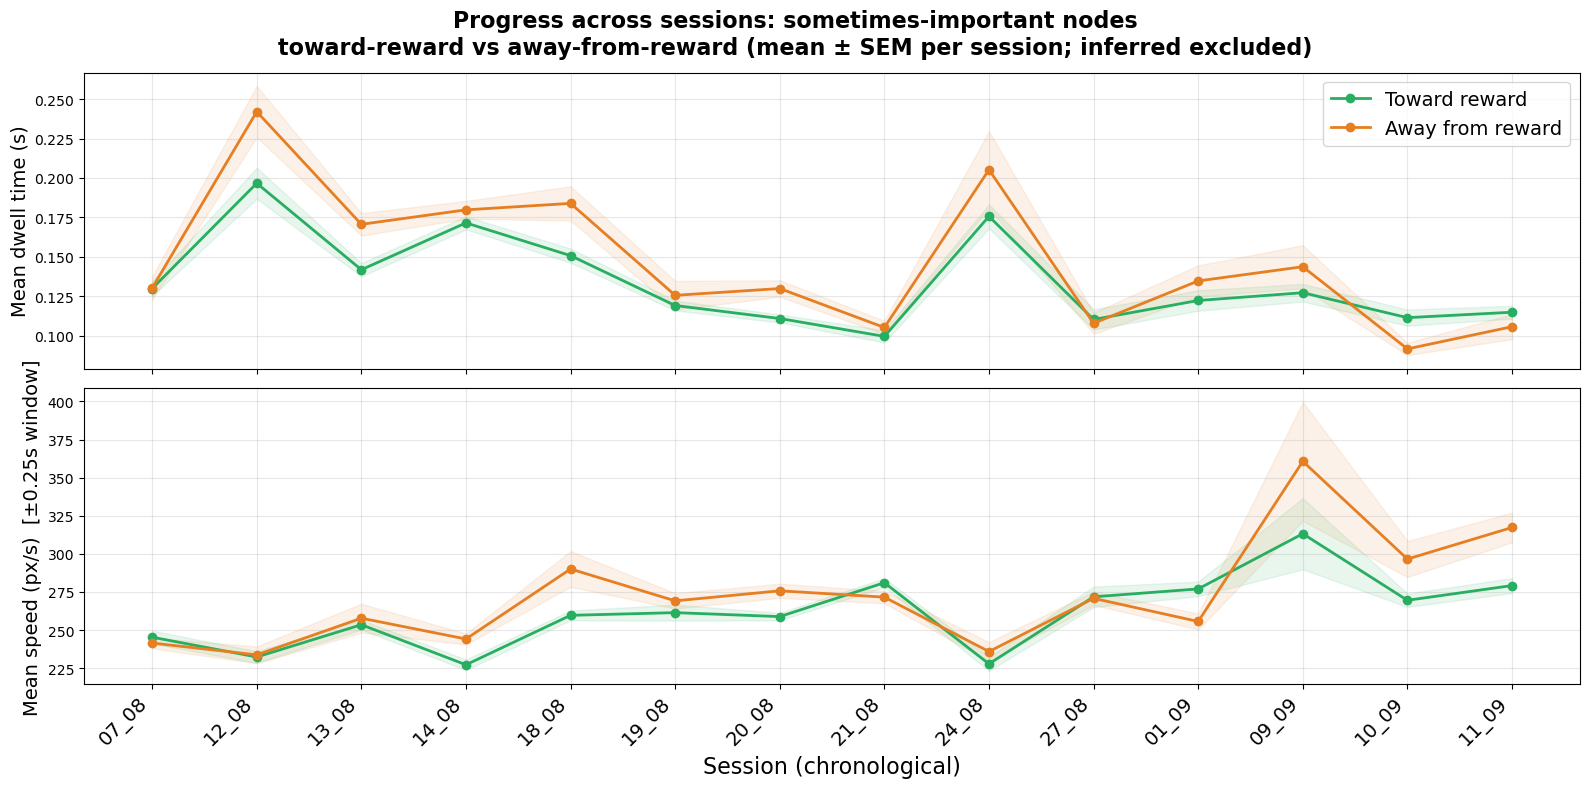

In [83]:
# ── Progress across sessions: sometimes-important nodes toward vs away ──────────
si_progress_style = {
    'toward_reward':    ('#27ae60', 'Toward reward'),
    'away_from_reward': ('#e67e22', 'Away from reward'),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, col, ylabel, si_src in [
    (axes[0], 'dwell_s',
     'Mean dwell time (s)',
     si_visits),
    (axes[1], 'mean_speed_pxs',
     f'Mean speed (px/s)  [\u00b1{VEL_WIN_S:.2f}s window]',
     si_visits_speed),
]:
    for dec, (color, label) in si_progress_style.items():
        ys, sems = [], []
        for sess in sessions_chron:
            vals = si_src[
                (si_src['session'] == sess) &
                (si_src['direction'] == dec)
            ][col].dropna()
            ys.append(vals.mean() if len(vals) > 0 else np.nan)
            sems.append(vals.sem()  if len(vals) > 1 else np.nan)
        ys   = np.array(ys,   dtype=float)
        sems = np.array(sems, dtype=float)
        xs   = np.arange(len(sessions_chron))
        ax.plot(xs, ys, 'o-', color=color, label=label, ms=6, linewidth=2)
        ax.fill_between(xs, ys - sems, ys + sems, color=color, alpha=0.1)
    ax.set_ylabel(ylabel, fontsize=14)
    # ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[1].set_xticks(range(len(sessions_chron)))
axes[1].set_xticklabels(session_labels, rotation=45, ha='right', fontsize=14)
axes[1].set_xlabel('Session (chronological)', fontsize=16)
axes[0].legend(loc='upper right', fontsize=14, framealpha=0.8)


fig.suptitle('Progress across sessions: sometimes-important nodes\n'
             'toward-reward vs away-from-reward (mean \u00b1 SEM per session; inferred excluded)',
             fontsize=16
             , fontweight='bold')
plt.tight_layout()
plt.show()
